# Pendulum Data Preprocessing (Lubricated)

Distilled workflow to get corrected data ready for smoothing/analysis.

**Key steps:**
1. Load tracking and field data
2. Preprocess (NaN handling, angle unwrapping)
3. Synchronize and interpolate to 2000 Hz
4. Apply drift correction (time-scaling)

**Output:** `theta_field_trim`, `theta_trk_trim`, `omega_trk_trim`, `alpha_trk_trim`, `mag_field_trim`, `t_trim`


In [1]:
%matplotlib widget

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Configuration
TRACK_FILE = 'chirp-data/lube3-1.csv'
FIELD_FILE = 'chirp3-lube.csv'
B_START = 214
B_END = 5181
FS_NEW = 2000  # Hz
T_START = 0
T_END = 5
TRIM_END = 5181  # Final length after resampling


## Step 1: Load and Preprocess Tracking Data

In [2]:
# Load tracking data (CSV has 2 header rows)
track_tbl = pd.read_csv(TRACK_FILE, header=1)

t_trk = track_tbl['t'].values
theta_trk = track_tbl['θ'].values / 180 * np.pi  # Convert to radians (already unwrapped)
omega_trk = track_tbl['ω'].values / 180 * np.pi  # Convert to rad/s

# Handle NaN values (backward fill then forward fill)
if np.isnan(omega_trk).sum() > 0:
    omega_series = pd.Series(omega_trk)
    omega_trk = omega_series.bfill().ffill().values

if np.isnan(theta_trk).sum() > 0:
    theta_series = pd.Series(theta_trk)
    theta_trk = theta_series.bfill().ffill().values

print(f"Loaded {len(t_trk)} tracking samples")
print(f"Time range: [{t_trk[0]:.3f}, {t_trk[-1]:.3f}] s")
print(f"Theta range: [{np.min(theta_trk):.2f}, {np.max(theta_trk):.2f}] rad")

Loaded 10070 tracking samples
Time range: [0.000, 5.035] s
Theta range: [-95.44, 121.45] rad


## Step 2: Load and Preprocess Field Data

In [3]:
# Load field data (skip 6 header rows, semicolon-separated)
field_tbl = pd.read_csv(FIELD_FILE, skiprows=6, sep=';')

idx = field_tbl['Index'].values
t_field = idx * 1e-3  # Convert ms to seconds
t_field = t_field[B_START:B_END]  # Trim to relevant window

Bx = field_tbl['Bx[mT]'].values[B_START:B_END]
By = field_tbl['By[mT]'].values[B_START:B_END]
Bz = field_tbl['Bz[mT]'].values[B_START:B_END]

# Compute field angle (wrapped to [-π, π])
theta_field_wrapped = np.arctan2(Bz, By)

# Unwrap field angle to make it continuous (removes discontinuities at ±π)
theta_field = np.unwrap(theta_field_wrapped)

mag_field = np.linalg.norm([By, Bz], axis=0)

print(f"Loaded {len(t_field)} field samples")
print(f"Time range: [{t_field[0]:.3f}, {t_field[-1]:.3f}] s")
print(f"Field angle range: [{np.min(theta_field):.2f}, {np.max(theta_field):.2f}] rad")

Loaded 4967 field samples
Time range: [0.215, 5.181] s
Field angle range: [-95.32, 120.78] rad


## Step 3: Synchronize and Interpolate to 2000 Hz

In [4]:
# Create uniform time grid at 2000 Hz
t_new = np.arange(T_START, T_END + 1/FS_NEW, 1/FS_NEW)

# Offset field time to start at zero
t_field_offset = t_field - t_field[0]

# Interpolate all signals to 2000 Hz using cubic spline
theta_field_spline = interp1d(t_field_offset, theta_field, kind='cubic',
                              bounds_error=False, fill_value='extrapolate')(t_new)
mag_field_spline = interp1d(t_field_offset, mag_field, kind='cubic',
                            bounds_error=False, fill_value='extrapolate')(t_new)
omega_trk_spline = interp1d(t_trk, omega_trk, kind='cubic',
                            bounds_error=False, fill_value='extrapolate')(t_new)
theta_trk_spline = interp1d(t_trk, theta_trk, kind='cubic',
                            bounds_error=False, fill_value='extrapolate')(t_new)

# Compute angular acceleration
alpha_trk_spline = np.gradient(omega_trk_spline, 1/FS_NEW)

# Trim to specified length
theta_field_trim = theta_field_spline[:TRIM_END]
mag_field_trim = mag_field_spline[:TRIM_END]
theta_trk_trim = theta_trk_spline[:TRIM_END]
omega_trk_trim = omega_trk_spline[:TRIM_END]
alpha_trk_trim = alpha_trk_spline[:TRIM_END]
t_trim = t_new[:TRIM_END]

print(f"Resampled to {FS_NEW} Hz")
print(f"Final length: {len(t_trim)} samples ({len(t_trim)/FS_NEW:.3f} seconds)")
print(f"Time range: [0, {t_trim[-1]:.4f}] s")

Resampled to 2000 Hz
Final length: 5181 samples (2.591 seconds)
Time range: [0, 2.5900] s


## Step 4: Detect and Apply Drift Correction

In [5]:
# Detect drift: compute phase difference and fit linear trend
phase_diff = theta_field_trim - theta_trk_trim
slope, intercept, r_value, p_value, _ = linregress(t_trim, phase_diff)

print("Drift Analysis:")
print(f"  Slope: {slope:.4f} rad/s ({slope*180/np.pi:.2f} deg/s)")
print(f"  Intercept: {intercept:.4f} rad ({intercept*180/np.pi:.2f}°)")
print(f"  R²: {r_value**2:.4f}")

if abs(slope) > 0.1:
    print(f"  → Significant drift detected: {slope*t_trim[-1]:.3f} rad ({slope*t_trim[-1]*180/np.pi:.1f}°) over {t_trim[-1]:.2f}s")
else:
    print(f"  → No significant drift detected")

Drift Analysis:
  Slope: 0.9915 rad/s (56.81 deg/s)
  Intercept: -1.3910 rad (-79.70°)
  R²: 0.0327
  → Significant drift detected: 2.568 rad (147.1°) over 2.59s



Clock Rate Correction:
  Average angular velocity: 241.52 rad/s
  Clock rate factor: 0.995895
  Clock mismatch: 4.105 parts per thousand

Quadratic Drift Fit:
  Constant term: 2.963494 rad
  Linear term: -9.098053 rad/s
  Quadratic term: 3.895587e+00 rad/s²

✓ Quadratic drift correction applied
  Remaining linear drift: -0.000000 rad/s
  Remaining quadratic: -7.770931e-16 rad/s²
  Residual R²: 0.0000

DRIFT CORRECTION: Before vs After Comparison


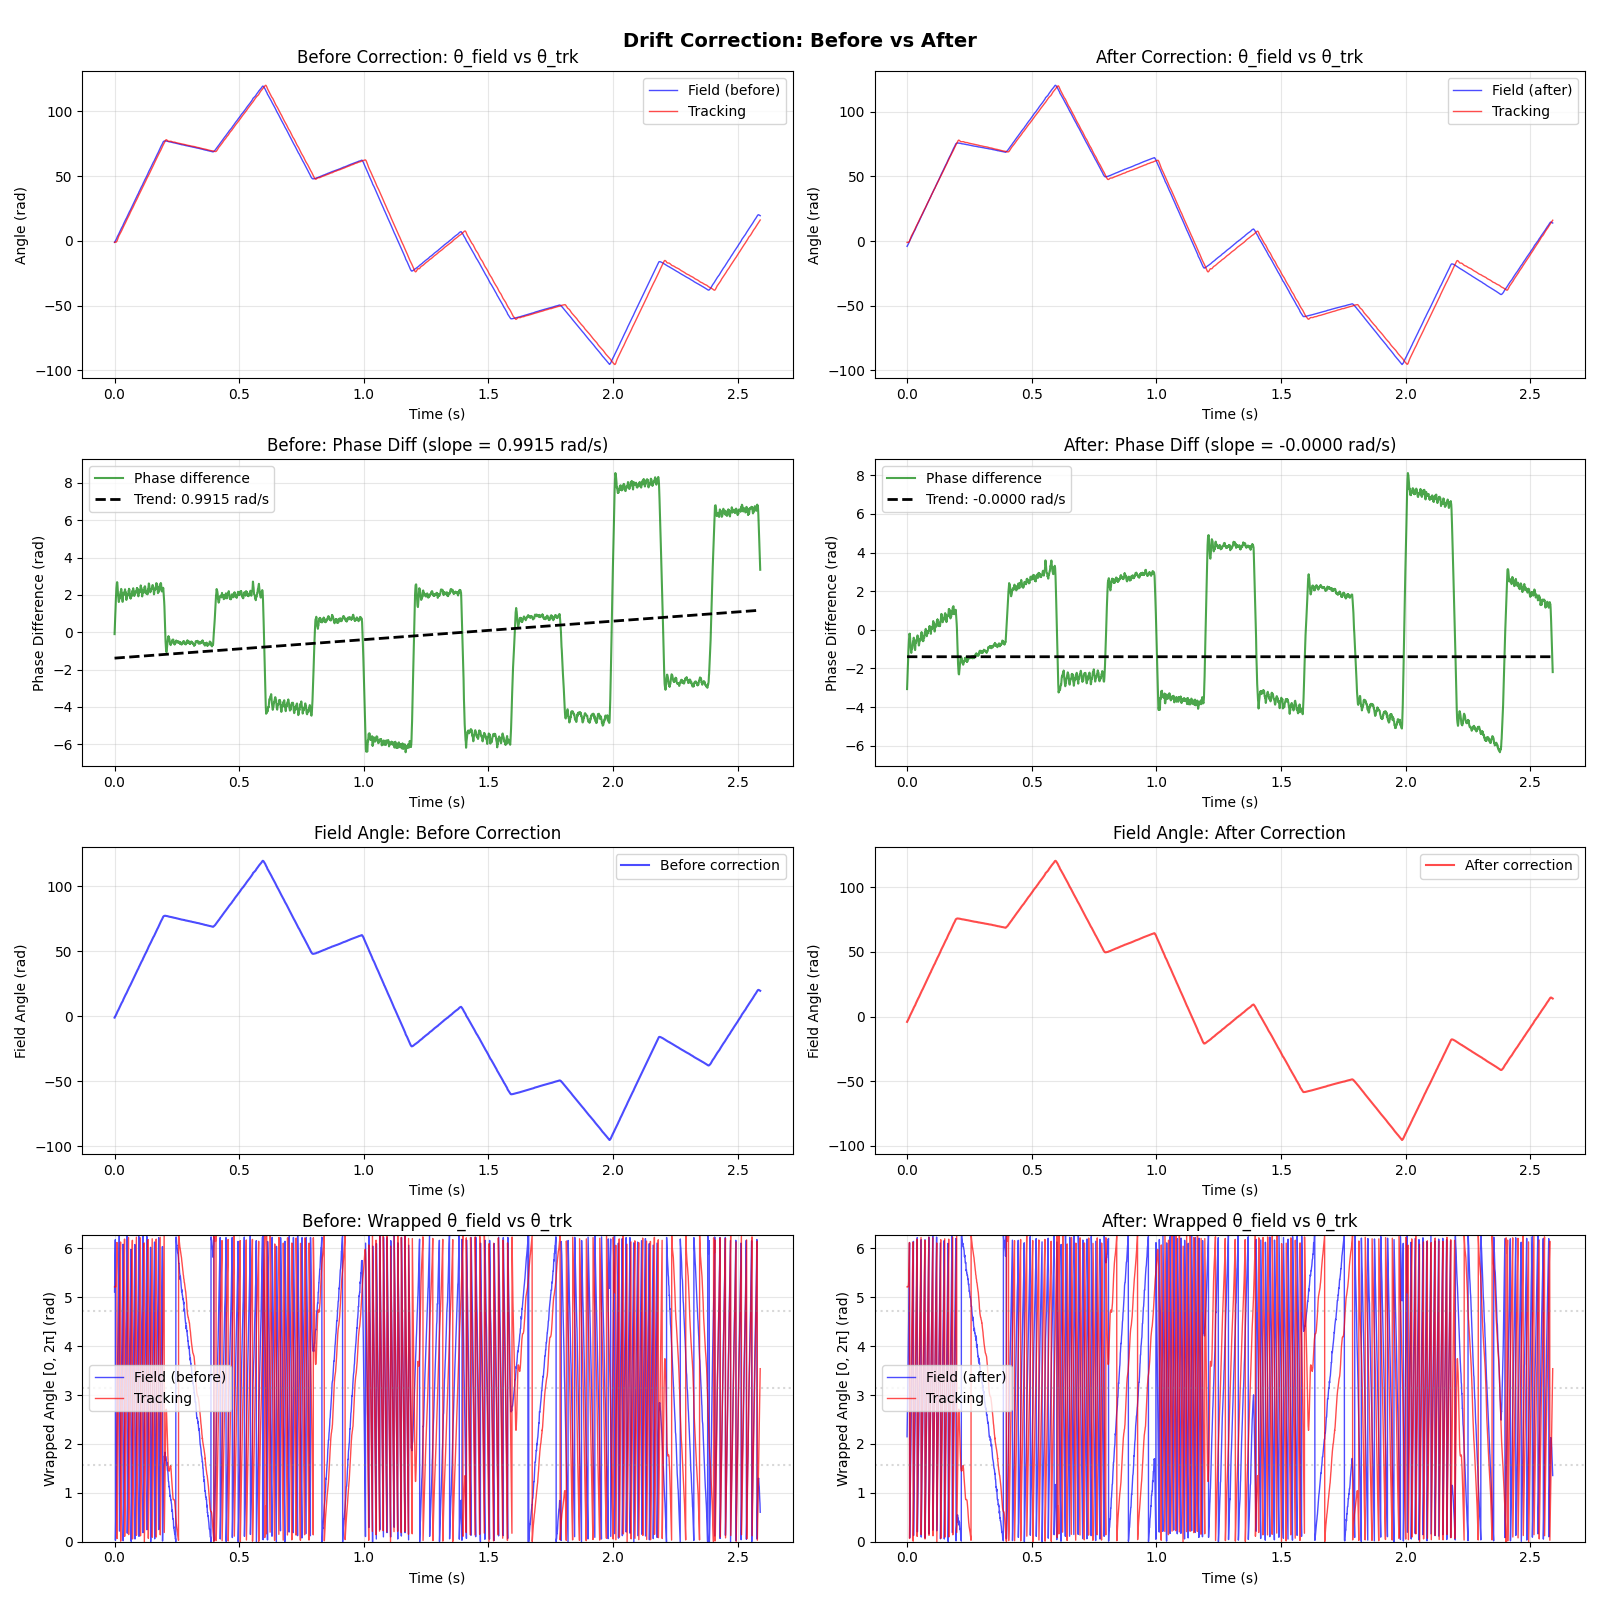


WRAPPED PHASE DIFFERENCE COMPARISON


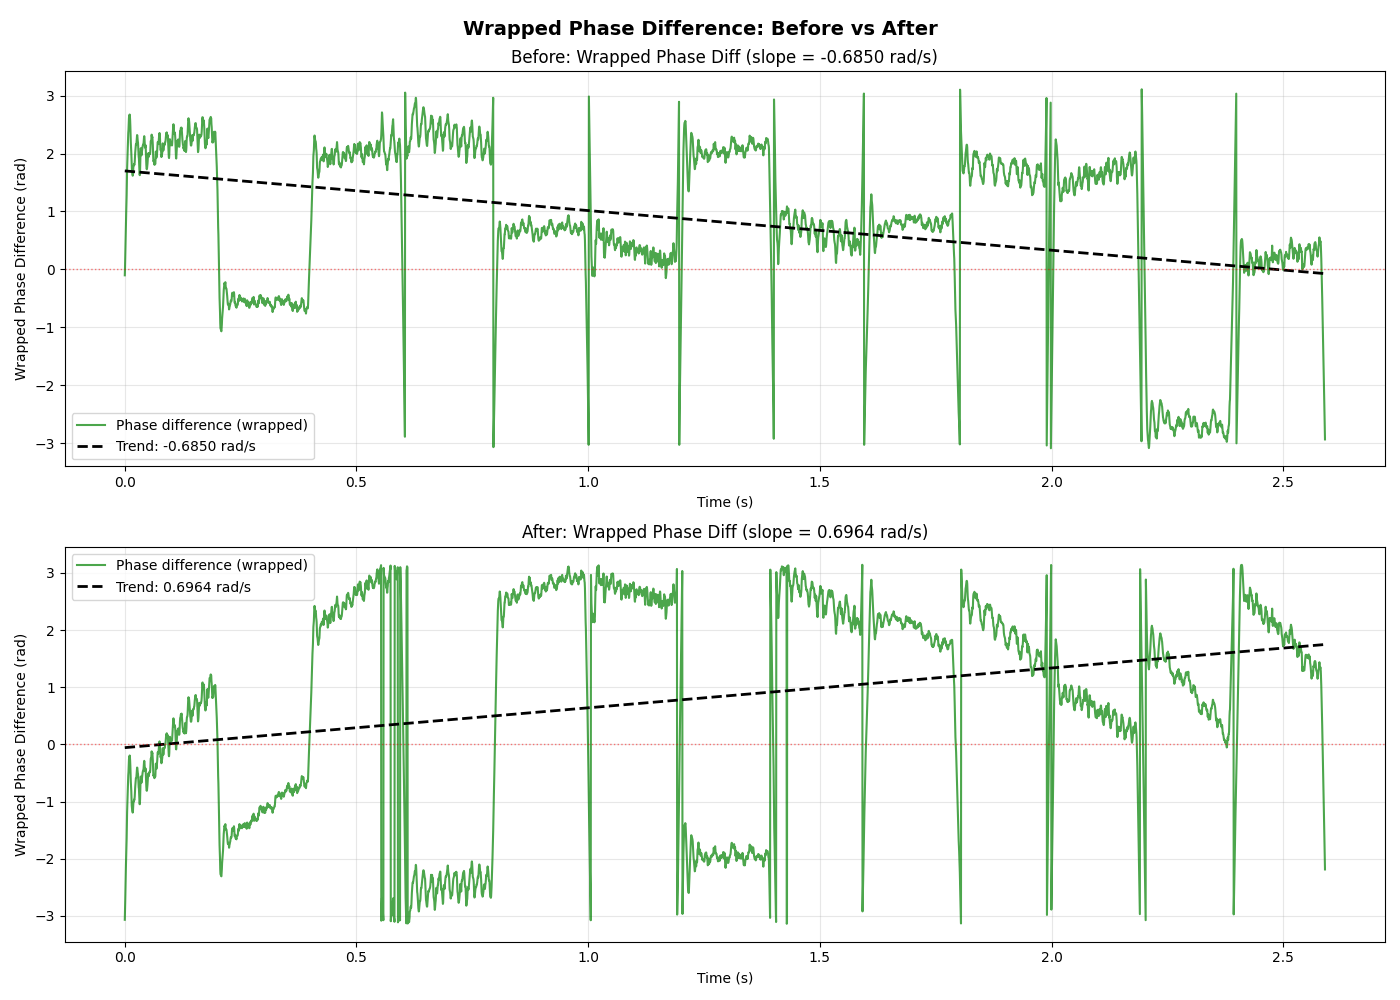


Summary:
  Before: Phase diff slope = 0.991517 rad/s
  After:  Phase diff slope = -0.000000 rad/s
  Improvement: 0.991517 rad/s (100.0% reduction)
  Quadratic drift correction applied successfully

DRIFT ANALYSIS: Current State


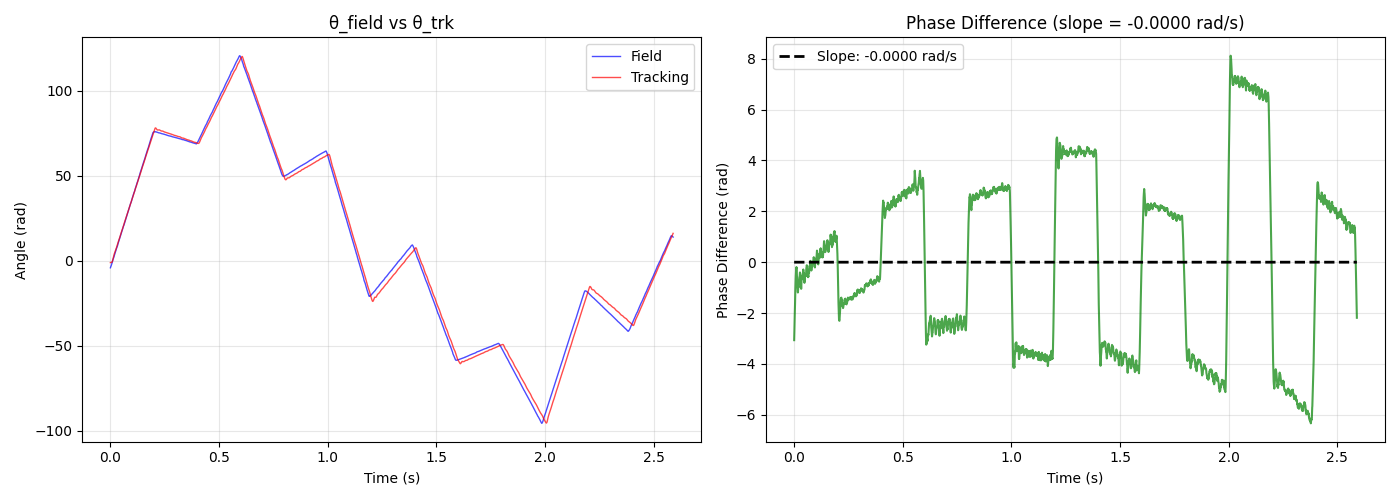

In [6]:
# Save original data BEFORE correction for visualization
theta_field_original_before_correction = theta_field_trim.copy()
theta_trk_original_before_correction = theta_trk_trim.copy()
t_original_before_correction = t_trim.copy()

# Apply drift correction: time-scaling to fix clock rate mismatch
omega_avg_field = np.mean(np.abs(np.gradient(theta_field_trim, 1/FS_NEW)))
clock_rate_factor = 1 - (slope / omega_avg_field)

print(f"\nClock Rate Correction:")
print(f"  Average angular velocity: {omega_avg_field:.2f} rad/s")
print(f"  Clock rate factor: {clock_rate_factor:.6f}")
print(f"  Clock mismatch: {abs(clock_rate_factor - 1.0)*1000:.3f} parts per thousand")

# Try QUADRATIC drift correction instead of linear time-scaling
from numpy.polynomial import Polynomial

# Fit quadratic to phase difference
phase_diff_for_fit = theta_field_original_before_correction - theta_trk_trim
poly_fit = Polynomial.fit(t_trim, phase_diff_for_fit, deg=2)
poly_coefs = poly_fit.convert().coef

# Extract coefficients: phase_diff = a0 + a1*t + a2*t^2
a0, a1, a2 = poly_coefs[0], poly_coefs[1] if len(poly_coefs) > 1 else 0, poly_coefs[2] if len(poly_coefs) > 2 else 0

print(f"\nQuadratic Drift Fit:")
print(f"  Constant term: {a0:.6f} rad")
print(f"  Linear term: {a1:.6f} rad/s")
print(f"  Quadratic term: {a2:.6e} rad/s²")

# Correct by subtracting the quadratic drift
phase_correction = a0 + a1 * t_trim + a2 * t_trim**2
theta_field_corrected = theta_field_original_before_correction - phase_correction

# Update theta_field_trim with corrected values
theta_field_trim = theta_field_corrected.copy()

print(f"\n✓ Quadratic drift correction applied")

# Verify correction
phase_diff_corrected = theta_field_trim - theta_trk_trim
slope_corrected, _, r_corrected, _, _ = linregress(t_trim, phase_diff_corrected)

# Check remaining quadratic component
poly_remaining = Polynomial.fit(t_trim, phase_diff_corrected, deg=2)
coefs_remaining = poly_remaining.convert().coef
quad_remaining = coefs_remaining[2] if len(coefs_remaining) > 2 else 0

print(f"  Remaining linear drift: {slope_corrected:.6f} rad/s")
print(f"  Remaining quadratic: {quad_remaining:.6e} rad/s²")
print(f"  Residual R²: {r_corrected**2:.4f}")

# Visualization: Before vs After Drift Correction
print(f"\n{'='*70}")
print("DRIFT CORRECTION: Before vs After Comparison")
print(f"{'='*70}")

# Wrap theta to [0, 2π] for closer examination
theta_field_before_wrapped = theta_field_original_before_correction % (2 * np.pi)
theta_trk_before_wrapped = theta_trk_original_before_correction % (2 * np.pi)
theta_field_after_wrapped = theta_field_trim % (2 * np.pi)
theta_trk_after_wrapped = theta_trk_trim % (2 * np.pi)

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
fig.suptitle('Drift Correction: Before vs After', fontsize=14, fontweight='bold')

# Row 1: Theta field vs tracking (overlapping)
axes[0, 0].plot(t_original_before_correction, theta_field_original_before_correction, 
                    'b-', label='Field (before)', linewidth=1, alpha=0.7)
axes[0, 0].plot(t_original_before_correction, theta_trk_original_before_correction, 
                    'r-', label='Tracking', linewidth=1, alpha=0.7)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Angle (rad)')
axes[0, 0].set_title('Before Correction: θ_field vs θ_trk')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_trim, theta_field_trim, 
                    'b-', label='Field (after)', linewidth=1, alpha=0.7)
axes[0, 1].plot(t_trim, theta_trk_trim, 
                    'r-', label='Tracking', linewidth=1, alpha=0.7)
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Angle (rad)')
axes[0, 1].set_title('After Correction: θ_field vs θ_trk')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Row 2: Phase difference over time
phase_diff_before = theta_field_original_before_correction - theta_trk_original_before_correction
phase_diff_after = theta_field_trim - theta_trk_trim

axes[1, 0].plot(t_original_before_correction, phase_diff_before, 
                    'g-', linewidth=1.5, alpha=0.7, label='Phase difference')
# Fit and plot trend line
slope_before, intercept_before, _, _, _ = linregress(t_original_before_correction, phase_diff_before)
trend_before = slope_before * t_original_before_correction + intercept_before
axes[1, 0].plot(t_original_before_correction, trend_before, 
                    'k--', linewidth=2, label=f'Trend: {slope_before:.4f} rad/s')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Phase Difference (rad)')
axes[1, 0].set_title(f'Before: Phase Diff (slope = {slope_before:.4f} rad/s)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t_trim, phase_diff_after, 
                    'g-', linewidth=1.5, alpha=0.7, label='Phase difference')
# Fit and plot trend line
trend_after = slope_corrected * t_trim + intercept_before  # Keep same intercept for comparison
axes[1, 1].plot(t_trim, trend_after, 
                    'k--', linewidth=2, label=f'Trend: {slope_corrected:.4f} rad/s')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Phase Difference (rad)')
axes[1, 1].set_title(f'After: Phase Diff (slope = {slope_corrected:.4f} rad/s)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Row 3: Direct comparison - field angles
axes[2, 0].plot(t_original_before_correction, theta_field_original_before_correction, 
                    'b-', label='Before correction', linewidth=1.5, alpha=0.7)
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].set_ylabel('Field Angle (rad)')
axes[2, 0].set_title('Field Angle: Before Correction')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].plot(t_trim, theta_field_trim, 
                'r-', label='After correction', linewidth=1.5, alpha=0.7)
axes[2, 1].set_xlabel('Time (s)')
axes[2, 1].set_ylabel('Field Angle (rad)')
axes[2, 1].set_title('Field Angle: After Correction')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

# Row 4: Wrapped theta comparison [0, 2π]
axes[3, 0].plot(t_original_before_correction, theta_field_before_wrapped, 
                    'b-', label='Field (before)', linewidth=1, alpha=0.7)
axes[3, 0].plot(t_original_before_correction, theta_trk_before_wrapped, 
                    'r-', label='Tracking', linewidth=1, alpha=0.7)
axes[3, 0].set_xlabel('Time (s)')
axes[3, 0].set_ylabel('Wrapped Angle [0, 2π] (rad)')
axes[3, 0].set_title('Before: Wrapped θ_field vs θ_trk')
axes[3, 0].set_ylim(0, 2*np.pi)
axes[3, 0].legend()
axes[3, 0].grid(True, alpha=0.3)
# Add y-axis labels for key angles
axes[3, 0].axhline(y=np.pi/2, color='gray', linestyle=':', alpha=0.3)
axes[3, 0].axhline(y=np.pi, color='gray', linestyle=':', alpha=0.3)
axes[3, 0].axhline(y=3*np.pi/2, color='gray', linestyle=':', alpha=0.3)

axes[3, 1].plot(t_trim, theta_field_after_wrapped, 
                    'b-', label='Field (after)', linewidth=1, alpha=0.7)
axes[3, 1].plot(t_trim, theta_trk_after_wrapped, 
                    'r-', label='Tracking', linewidth=1, alpha=0.7)
axes[3, 1].set_xlabel('Time (s)')
axes[3, 1].set_ylabel('Wrapped Angle [0, 2π] (rad)')
axes[3, 1].set_title('After: Wrapped θ_field vs θ_trk')
axes[3, 1].set_ylim(0, 2*np.pi)
axes[3, 1].legend()
axes[3, 1].grid(True, alpha=0.3)
# Add y-axis labels for key angles
axes[3, 1].axhline(y=np.pi/2, color='gray', linestyle=':', alpha=0.3)
axes[3, 1].axhline(y=np.pi, color='gray', linestyle=':', alpha=0.3)
axes[3, 1].axhline(y=3*np.pi/2, color='gray', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

# Additional plot: Wrapped phase difference (may be more revealing)
print(f"\n{'='*70}")
print("WRAPPED PHASE DIFFERENCE COMPARISON")
print(f"{'='*70}")

phase_diff_before_wrapped = (theta_field_before_wrapped - theta_trk_before_wrapped + np.pi) % (2 * np.pi) - np.pi
phase_diff_after_wrapped = (theta_field_after_wrapped - theta_trk_after_wrapped + np.pi) % (2 * np.pi) - np.pi

fig2, axes2 = plt.subplots(2, 1, figsize=(14, 10))
fig2.suptitle('Wrapped Phase Difference: Before vs After', fontsize=14, fontweight='bold')

axes2[0].plot(t_original_before_correction, phase_diff_before_wrapped, 
                  'g-', linewidth=1.5, alpha=0.7, label='Phase difference (wrapped)')
# Fit and plot trend line
slope_before_wrapped, intercept_before_wrapped, _, _, _ = linregress(t_original_before_correction, phase_diff_before_wrapped)
trend_before_wrapped = slope_before_wrapped * t_original_before_correction + intercept_before_wrapped
axes2[0].plot(t_original_before_correction, trend_before_wrapped, 
                  'k--', linewidth=2, label=f'Trend: {slope_before_wrapped:.4f} rad/s')
axes2[0].axhline(y=0, color='r', linestyle=':', linewidth=1, alpha=0.5)
axes2[0].set_xlabel('Time (s)')
axes2[0].set_ylabel('Wrapped Phase Difference (rad)')
axes2[0].set_title(f'Before: Wrapped Phase Diff (slope = {slope_before_wrapped:.4f} rad/s)')
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)

axes2[1].plot(t_trim, phase_diff_after_wrapped, 
                  'g-', linewidth=1.5, alpha=0.7, label='Phase difference (wrapped)')
# Fit and plot trend line
slope_after_wrapped, intercept_after_wrapped, _, _, _ = linregress(t_trim, phase_diff_after_wrapped)
trend_after_wrapped = slope_after_wrapped * t_trim + intercept_after_wrapped
axes2[1].plot(t_trim, trend_after_wrapped, 
                  'k--', linewidth=2, label=f'Trend: {slope_after_wrapped:.4f} rad/s')
axes2[1].axhline(y=0, color='r', linestyle=':', linewidth=1, alpha=0.5)
axes2[1].set_xlabel('Time (s)')
axes2[1].set_ylabel('Wrapped Phase Difference (rad)')
axes2[1].set_title(f'After: Wrapped Phase Diff (slope = {slope_after_wrapped:.4f} rad/s)')
axes2[1].legend()
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nSummary:")
print(f"  Before: Phase diff slope = {slope_before:.6f} rad/s")
print(f"  After:  Phase diff slope = {slope_corrected:.6f} rad/s")
print(f"  Improvement: {abs(slope_before) - abs(slope_corrected):.6f} rad/s ({((abs(slope_before) - abs(slope_corrected))/abs(slope_before)*100):.1f}% reduction)")
print(f"  Quadratic drift correction applied successfully")

# Still show before comparison even if no correction
print(f"\n{'='*70}")
print("DRIFT ANALYSIS: Current State")
print(f"{'='*70}")

phase_diff_current = theta_field_trim - theta_trk_trim
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t_trim, theta_field_trim, 'b-', label='Field', linewidth=1, alpha=0.7)
axes[0].plot(t_trim, theta_trk_trim, 'r-', label='Tracking', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Angle (rad)')
axes[0].set_title('θ_field vs θ_trk')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_trim, phase_diff_current, 'g-', linewidth=1.5, alpha=0.7)
slope_current, intercept_current, _, _, _ = linregress(t_trim, phase_diff_current)
trend_current = slope_current * t_trim + intercept_current
axes[1].plot(t_trim, trend_current, 'k--', linewidth=2, 
                 label=f'Slope: {slope_current:.4f} rad/s')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Phase Difference (rad)')
axes[1].set_title(f'Phase Difference (slope = {slope_current:.4f} rad/s)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
## Step 5: Compute Forces and 3D Visualization

# Physical parameters for force computation
J_INITIAL = 9.33e-12  # Moment of inertia (kg⋅m²)
B_MAGNET_INITIAL = 0.00113  # Magnetic moment (A⋅m²)

# Compute magnetic torque and friction force
B_ext = mag_field_trim * 1e-3  # Convert mT to T
B_const = B_MAGNET_INITIAL * B_ext
torque = B_const * np.sin(theta_field_trim - theta_trk_trim)
frc = torque - J_INITIAL * alpha_trk_trim

print(f"Force Computation:")
print(f"  Torque range: [{np.min(torque):.6e}, {np.max(torque):.6e}] N⋅m")
print(f"  Friction range: [{np.min(frc):.6e}, {np.max(frc):.6e}] N⋅m")
print(f"  Torque std: {np.std(torque):.6e} N⋅m")
print(f"  Friction std: {np.std(frc):.6e} N⋅m")

# Compute friction BEFORE drift correction for comparison
# Check if original data exists (saved in drift correction cell)
if 'theta_field_original_before_correction' in locals() or 'theta_field_original_before_correction' in globals():
    print(f"\n{'='*70}")
    print("COMPARING FRICTION: Before vs After Drift Correction")
    print(f"{'='*70}")
    
    # Compute friction before correction
    B_ext_before = mag_field_trim * 1e-3  # Convert mT to T
    B_const_before = B_MAGNET_INITIAL * B_ext_before
    torque_before = B_const_before * np.sin(theta_field_original_before_correction - theta_trk_trim)
    frc_before = torque_before - J_INITIAL * alpha_trk_trim
    
    # Current friction (after correction)
    frc_after = frc.copy()
    
    print(f"\nFriction Statistics:")
    print(f"  Before correction: range=[{np.min(frc_before):.6e}, {np.max(frc_before):.6e}], std={np.std(frc_before):.6e}")
    print(f"  After correction:  range=[{np.min(frc_after):.6e}, {np.max(frc_after):.6e}], std={np.std(frc_after):.6e}")
    print(f"  Difference std: {np.std(frc_after - frc_before):.6e}")
    print(f"  Mean difference: {np.mean(frc_after - frc_before):.6e}")
    
    # 3D Visualization: Compare friction before and after
    import plotly.graph_objects as go
    
    # Prepare state space coordinates (same as earlier plots)
    omega_offset = omega_trk_trim - np.min(omega_trk_trim)
    theta_wrapped_viz = theta_trk_trim % (2 * np.pi)
    
    x_coords = omega_offset * np.cos(theta_wrapped_viz)
    y_coords = omega_offset * np.sin(theta_wrapped_viz)
    
    # Common camera position
    camera = dict(eye=dict(x=1.5, y=1.5, z=1.2))
    
    # Plot 1: Friction BEFORE correction
    fig_before = go.Figure(data=[go.Scatter3d(
        x=x_coords,
        y=y_coords,
        z=frc_before,
        mode='markers',
        marker=dict(
            size=2,
            color=frc_before,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Friction (N⋅m)", x=1.15, len=0.7, thickness=15),
            opacity=0.6
        ),
        text=[f"θ={theta_wrapped_viz[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_before[i]:.2e} N⋅m" 
              for i in range(len(frc_before))],
        hovertemplate='%{text}<extra></extra>'
    )])
    
    fig_before.update_layout(
        title='Friction BEFORE Drift Correction<br>std=' + f'{np.std(frc_before):.6e} N⋅m',
        scene=dict(
            xaxis_title='ω·cos(θ) (rad/s)',
            yaxis_title='ω·sin(θ) (rad/s)',
            zaxis_title='Friction (N⋅m)',
            aspectmode='cube'
        ),
        width=700,
        height=600,
        margin=dict(r=100),
        scene_camera=camera
    )
    
    # Plot 2: Friction AFTER correction
    fig_after = go.Figure(data=[go.Scatter3d(
        x=x_coords,
        y=y_coords,
        z=frc_after,
        mode='markers',
        marker=dict(
            size=2,
            color=frc_after,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Friction (N⋅m)", x=1.15, len=0.7, thickness=15),
            opacity=0.6
        ),
        text=[f"θ={theta_wrapped_viz[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_after[i]:.2e} N⋅m" 
              for i in range(len(frc_after))],
        hovertemplate='%{text}<extra></extra>'
    )])
    
    fig_after.update_layout(
        title='Friction AFTER Drift Correction<br>std=' + f'{np.std(frc_after):.6e} N⋅m',
        scene=dict(
            xaxis_title='ω·cos(θ) (rad/s)',
            yaxis_title='ω·sin(θ) (rad/s)',
            zaxis_title='Friction (N⋅m)',
            aspectmode='cube'
        ),
        width=700,
        height=600,
        margin=dict(r=100),
        scene_camera=camera
    )
    
    # Plot 3: Difference (After - Before)
    frc_diff = frc_after - frc_before
    
    fig_diff = go.Figure(data=[go.Scatter3d(
        x=x_coords,
        y=y_coords,
        z=frc_diff,
        mode='markers',
        marker=dict(
            size=2,
            color=frc_diff,
            colorscale='RdBu',
            showscale=True,
            colorbar=dict(title="ΔFriction (N⋅m)", x=1.15, len=0.7, thickness=15),
            opacity=0.6,
            cmin=-np.max(np.abs(frc_diff)),
            cmax=np.max(np.abs(frc_diff))
        ),
        text=[f"θ={theta_wrapped_viz[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>ΔF={frc_diff[i]:.2e} N⋅m" 
              for i in range(len(frc_diff))],
        hovertemplate='%{text}<extra></extra>'
    )])
    
    fig_diff.update_layout(
        title='Friction Difference (After - Before)<br>std=' + f'{np.std(frc_diff):.6e} N⋅m',
        scene=dict(
            xaxis_title='ω·cos(θ) (rad/s)',
            yaxis_title='ω·sin(θ) (rad/s)',
            zaxis_title='ΔFriction (N⋅m)',
            aspectmode='cube'
        ),
        width=700,
        height=600,
        margin=dict(r=100),
        scene_camera=camera
    )
    
    print("\nShowing 3D friction visualizations:")
    print("  1. BEFORE drift correction")
    print("  2. AFTER drift correction")
    print("  3. DIFFERENCE (After - Before)")
    
    fig_before.show()
    fig_after.show()
    fig_diff.show()
    
    print(f"\n✓ 3D friction comparison complete")
else:
    print("\n⚠ Original data before correction not available. Run drift correction cell first.")

Force Computation:
  Torque range: [-3.276469e-06, 3.677062e-06] N⋅m
  Friction range: [-4.520347e-06, 4.169579e-06] N⋅m
  Torque std: 1.828457e-06 N⋅m
  Friction std: 1.862241e-06 N⋅m

COMPARING FRICTION: Before vs After Drift Correction

Friction Statistics:
  Before correction: range=[-3.526843e-06, 4.326339e-06], std=1.509235e-06
  After correction:  range=[-4.520347e-06, 4.169579e-06], std=1.862241e-06
  Difference std: 2.189854e-06
  Mean difference: -6.382479e-07

Showing 3D friction visualizations:
  1. BEFORE drift correction
  2. AFTER drift correction
  3. DIFFERENCE (After - Before)



✓ 3D friction comparison complete


DIAGNOSTIC: Data Quality and Synchronization Analysis

1. RAW DATA QUALITY CHECK
----------------------------------------------------------------------
  Bounds: B_START=214, B_END=5181
  Field data length: 5181
  Tracking data length: 5181
  NaN values in field data: 0
  NaN values in tracking data: 0

2. PHASE DIFFERENCE ANALYSIS
----------------------------------------------------------------------
  Linear fit: slope=0.991517 rad/s, R²=0.0327
  Quadratic term: 3.895587e+00 rad/s²
  P-value (linear): 2.66e-39
  ⚠ Warning: Significant nonlinear (quadratic) drift detected!
     This suggests time-scaling alone may not be sufficient.

3. SEGMENT-WISE DRIFT ANALYSIS
----------------------------------------------------------------------
  Early segment (0.00s - 0.86s):
    Slope: -5.485603 rad/s, R²=0.3307
    ⚠ Slope differs from global fit by 6.4771 rad/s
  Middle segment (0.86s - 1.73s):
    Slope: 0.104156 rad/s, R²=0.0001
    ⚠ Slope differs from global fit by 0.8874 rad/s
  Late se

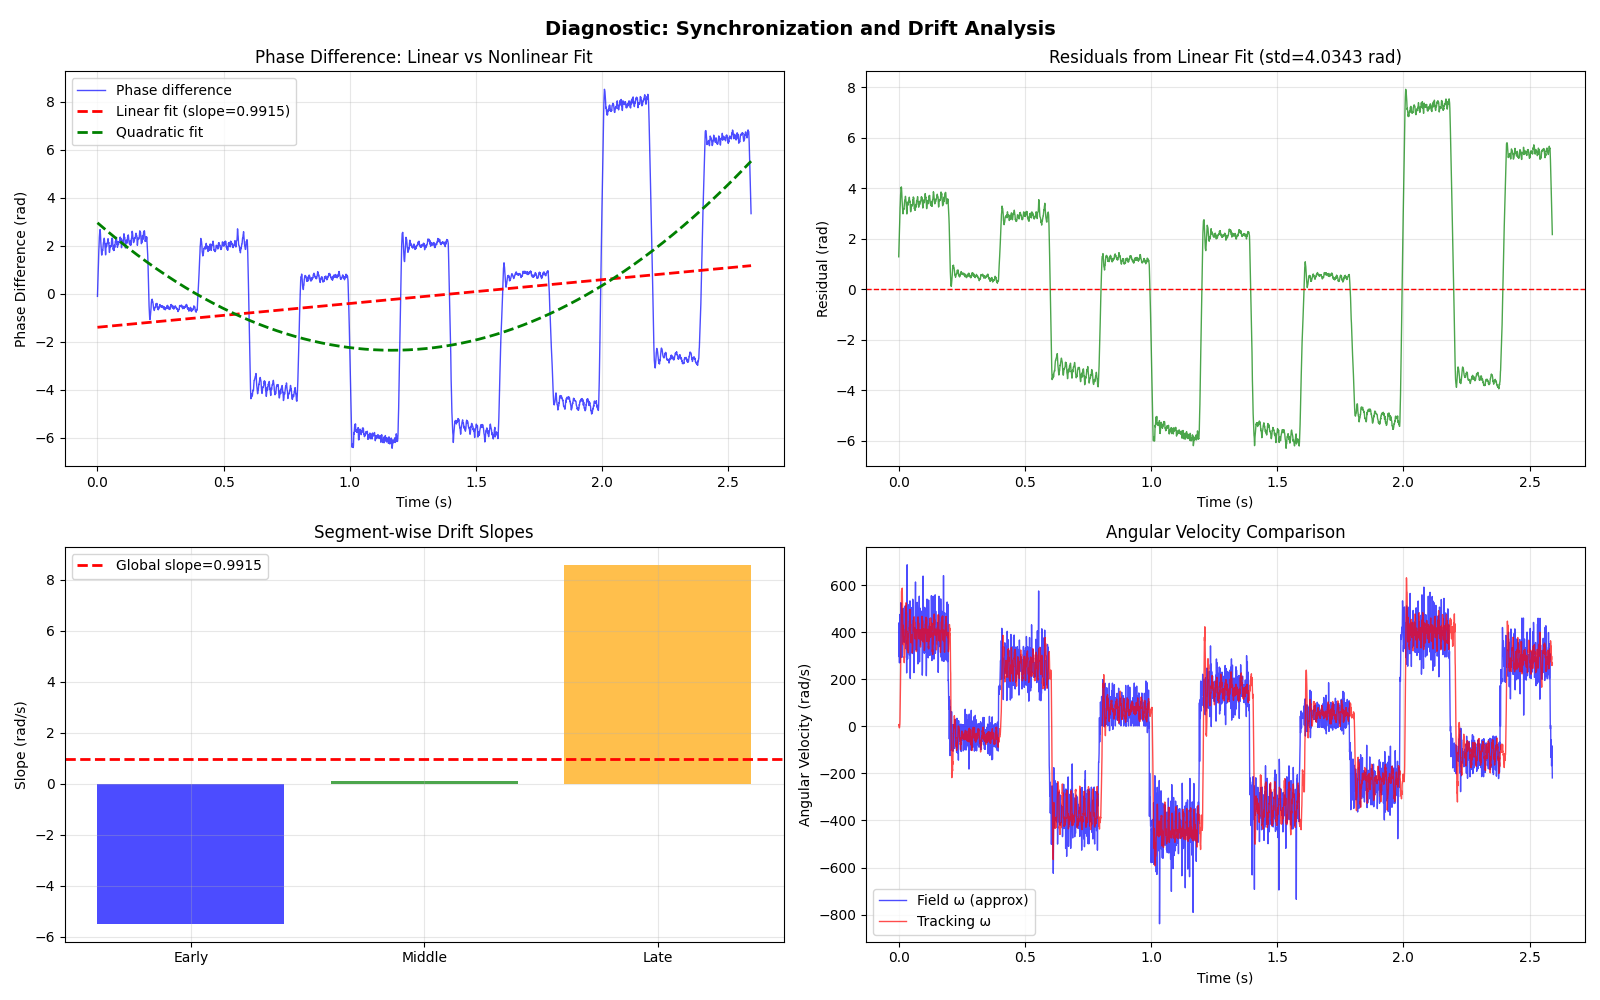


RECOMMENDATIONS
⚠ Significant nonlinear drift detected.
  Consider: Higher-order correction or different synchronization method
⚠ Large residuals from linear fit (std=4.0343 rad)
  Consider: Check for data quality issues or missing samples
⚠ Inconsistent drift across segments (max diff=7.5939 rad/s)
  Consider: Time-dependent correction or check for different regimes

✓ Diagnostic complete


In [8]:
# Diagnostic: Check Data Quality and Synchronization Issues

print("="*70)
print("DIAGNOSTIC: Data Quality and Synchronization Analysis")
print("="*70)

# Check 1: Examine raw data quality in the bounds region
print("\n1. RAW DATA QUALITY CHECK")
print("-" * 70)
print(f"  Bounds: B_START={B_START}, B_END={B_END}")
print(f"  Field data length: {len(mag_field_trim)}")
print(f"  Tracking data length: {len(theta_trk_trim)}")

# Check for NaN values
field_nan_count = np.isnan(mag_field_trim).sum()
trk_nan_count = np.isnan(theta_trk_trim).sum() + np.isnan(omega_trk_trim).sum()
print(f"  NaN values in field data: {field_nan_count}")
print(f"  NaN values in tracking data: {trk_nan_count}")

# Check 2: Phase difference analysis - is it truly linear?
print("\n2. PHASE DIFFERENCE ANALYSIS")
print("-" * 70)

# If original data exists, use it; otherwise use current
if 'theta_field_original_before_correction' in locals() or 'theta_field_original_before_correction' in globals():
    phase_diff_analysis = theta_field_original_before_correction - theta_trk_trim
    t_analysis = t_original_before_correction
else:
    phase_diff_analysis = theta_field_trim - theta_trk_trim
    t_analysis = t_trim

# Linear fit
slope_lin, intercept_lin, r_value_lin, p_value_lin, _ = linregress(t_analysis, phase_diff_analysis)

# Check for nonlinear trends - polynomial fit
from numpy.polynomial import Polynomial
poly_fit = Polynomial.fit(t_analysis, phase_diff_analysis, deg=2)
poly_coefs = poly_fit.convert().coef
quadratic_term = poly_coefs[2] if len(poly_coefs) > 2 else 0

print(f"  Linear fit: slope={slope_lin:.6f} rad/s, R²={r_value_lin**2:.4f}")
print(f"  Quadratic term: {quadratic_term:.6e} rad/s²")
print(f"  P-value (linear): {p_value_lin:.2e}")

if abs(quadratic_term) > 1e-5:
    print(f"  ⚠ Warning: Significant nonlinear (quadratic) drift detected!")
    print(f"     This suggests time-scaling alone may not be sufficient.")

# Check 3: Segment-wise drift analysis (early, middle, late)
print("\n3. SEGMENT-WISE DRIFT ANALYSIS")
print("-" * 70)

n_segments = 3
segment_size = len(t_analysis) // n_segments

for i in range(n_segments):
    start_idx = i * segment_size
    end_idx = (i + 1) * segment_size if i < n_segments - 1 else len(t_analysis)
    
    t_seg = t_analysis[start_idx:end_idx]
    phase_seg = phase_diff_analysis[start_idx:end_idx]
    
    slope_seg, _, r_seg, _, _ = linregress(t_seg, phase_seg)
    
    segment_name = ["Early", "Middle", "Late"][i]
    print(f"  {segment_name} segment ({t_seg[0]:.2f}s - {t_seg[-1]:.2f}s):")
    print(f"    Slope: {slope_seg:.6f} rad/s, R²={r_seg**2:.4f}")
    
    if abs(slope_seg - slope_lin) > 0.01:
        print(f"    ⚠ Slope differs from global fit by {abs(slope_seg - slope_lin):.4f} rad/s")

# Check 4: Angular velocity consistency
print("\n4. ANGULAR VELOCITY CONSISTENCY")
print("-" * 70)

omega_field_approx = np.gradient(theta_field_trim, 1/FS_NEW)
omega_trk_computed = omega_trk_trim

omega_diff = omega_field_approx - omega_trk_computed

print(f"  Field ω (approx from θ): range=[{np.min(omega_field_approx):.2f}, {np.max(omega_field_approx):.2f}] rad/s")
print(f"  Tracking ω: range=[{np.min(omega_trk_computed):.2f}, {np.max(omega_trk_computed):.2f}] rad/s")
print(f"  ω difference: std={np.std(omega_diff):.2f} rad/s, mean={np.mean(omega_diff):.2f} rad/s")

# Check 5: Visualization - detailed phase analysis
print("\n5. DETAILED PHASE DIFFERENCE VISUALIZATION")
print("-" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Diagnostic: Synchronization and Drift Analysis', fontsize=14, fontweight='bold')

# Plot 1: Full phase difference with linear and quadratic fits
axes[0, 0].plot(t_analysis, phase_diff_analysis, 'b-', linewidth=1, alpha=0.7, label='Phase difference')
linear_fit_line = slope_lin * t_analysis + intercept_lin
axes[0, 0].plot(t_analysis, linear_fit_line, 'r--', linewidth=2, label=f'Linear fit (slope={slope_lin:.4f})')

# Quadratic fit
poly_vals = poly_fit(t_analysis)
axes[0, 0].plot(t_analysis, poly_vals, 'g--', linewidth=2, label=f'Quadratic fit')

axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Phase Difference (rad)')
axes[0, 0].set_title('Phase Difference: Linear vs Nonlinear Fit')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals from linear fit
residuals_linear = phase_diff_analysis - linear_fit_line
axes[0, 1].plot(t_analysis, residuals_linear, 'g-', linewidth=1, alpha=0.7)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Residual (rad)')
axes[0, 1].set_title(f'Residuals from Linear Fit (std={np.std(residuals_linear):.4f} rad)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Segment-wise slopes
segment_slopes = []
segment_times = []
for i in range(n_segments):
    start_idx = i * segment_size
    end_idx = (i + 1) * segment_size if i < n_segments - 1 else len(t_analysis)
    t_seg = t_analysis[start_idx:end_idx]
    phase_seg = phase_diff_analysis[start_idx:end_idx]
    slope_seg, _, _, _, _ = linregress(t_seg, phase_seg)
    segment_slopes.append(slope_seg)
    segment_times.append((t_seg[0] + t_seg[-1]) / 2)

axes[1, 0].bar(range(n_segments), segment_slopes, color=['blue', 'green', 'orange'], alpha=0.7)
axes[1, 0].axhline(y=slope_lin, color='r', linestyle='--', linewidth=2, label=f'Global slope={slope_lin:.4f}')
axes[1, 0].set_xticks(range(n_segments))
axes[1, 0].set_xticklabels(['Early', 'Middle', 'Late'])
axes[1, 0].set_ylabel('Slope (rad/s)')
axes[1, 0].set_title('Segment-wise Drift Slopes')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Angular velocity comparison
axes[1, 1].plot(t_trim, omega_field_approx, 'b-', label='Field ω (approx)', linewidth=1, alpha=0.7)
axes[1, 1].plot(t_trim, omega_trk_computed, 'r-', label='Tracking ω', linewidth=1, alpha=0.7)
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Angular Velocity (rad/s)')
axes[1, 1].set_title('Angular Velocity Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary recommendations
print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)

if abs(quadratic_term) > 1e-5:
    print("⚠ Significant nonlinear drift detected.")
    print("  Consider: Higher-order correction or different synchronization method")

if np.std(residuals_linear) > 0.1:
    print(f"⚠ Large residuals from linear fit (std={np.std(residuals_linear):.4f} rad)")
    print("  Consider: Check for data quality issues or missing samples")

max_slope_diff = max([abs(s - slope_lin) for s in segment_slopes])
if max_slope_diff > 0.01:
    print(f"⚠ Inconsistent drift across segments (max diff={max_slope_diff:.4f} rad/s)")
    print("  Consider: Time-dependent correction or check for different regimes")

print(f"\n✓ Diagnostic complete")


In [9]:
# Try computing friction WITHOUT drift correction for comparison

print("="*70)
print("EXPERIMENT: Friction WITHOUT Drift Correction")
print("="*70)
print("\nGiven the strong nonlinear drift, let's compare friction computed:")
print("  1. WITH drift correction (current)")
print("  2. WITHOUT drift correction (original data)")
print("\nThis will help determine if the drift correction is actually helping or hurting.\n")

# Check if original data exists
if 'theta_field_original_before_correction' in locals() or 'theta_field_original_before_correction' in globals():
    # Compute friction with original (uncorrected) data
    B_ext_orig = mag_field_trim * 1e-3
    B_const_orig = B_MAGNET_INITIAL * B_ext_orig
    torque_orig = B_const_orig * np.sin(theta_field_original_before_correction - theta_trk_trim)
    frc_no_correction = torque_orig - J_INITIAL * alpha_trk_trim
    
    # Current friction (with correction)
    frc_with_correction = frc.copy()
    
    # Statistics comparison
    print("Friction Statistics Comparison:")
    print("-" * 70)
    print(f"WITHOUT correction:")
    print(f"  Range: [{np.min(frc_no_correction):.6e}, {np.max(frc_no_correction):.6e}] N⋅m")
    print(f"  Std:   {np.std(frc_no_correction):.6e} N⋅m")
    print(f"  Mean:  {np.mean(frc_no_correction):.6e} N⋅m")
    print(f"\nWITH correction:")
    print(f"  Range: [{np.min(frc_with_correction):.6e}, {np.max(frc_with_correction):.6e}] N⋅m")
    print(f"  Std:   {np.std(frc_with_correction):.6e} N⋅m")
    print(f"  Mean:  {np.mean(frc_with_correction):.6e} N⋅m")
    print(f"\nDifference:")
    print(f"  Std change: {np.std(frc_with_correction) - np.std(frc_no_correction):.6e} N⋅m")
    print(f"  Mean change: {np.mean(frc_with_correction) - np.mean(frc_no_correction):.6e} N⋅m")
    
    # 3D comparison: Without vs With correction
    import plotly.graph_objects as go
    
    omega_offset = omega_trk_trim - np.min(omega_trk_trim)
    theta_wrapped_viz = theta_trk_trim % (2 * np.pi)
    x_coords = omega_offset * np.cos(theta_wrapped_viz)
    y_coords = omega_offset * np.sin(theta_wrapped_viz)
    
    camera = dict(eye=dict(x=1.5, y=1.5, z=1.2))
    
    # Plot 1: WITHOUT correction
    fig_no_corr = go.Figure(data=[go.Scatter3d(
        x=x_coords,
        y=y_coords,
        z=frc_no_correction,
        mode='markers',
        marker=dict(
            size=2,
            color=frc_no_correction,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Friction (N⋅m)", x=1.15, len=0.7, thickness=15),
            opacity=0.6
        ),
        text=[f"θ={theta_wrapped_viz[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_no_correction[i]:.2e} N⋅m" 
              for i in range(len(frc_no_correction))],
        hovertemplate='%{text}<extra></extra>'
    )])
    
    fig_no_corr.update_layout(
        title=f'Friction WITHOUT Drift Correction<br>std={np.std(frc_no_correction):.6e} N⋅m',
        scene=dict(
            xaxis_title='ω·cos(θ) (rad/s)',
            yaxis_title='ω·sin(θ) (rad/s)',
            zaxis_title='Friction (N⋅m)',
            aspectmode='cube'
        ),
        width=700,
        height=600,
        margin=dict(r=100),
        scene_camera=camera
    )
    
    # Plot 2: WITH correction
    fig_with_corr = go.Figure(data=[go.Scatter3d(
        x=x_coords,
        y=y_coords,
        z=frc_with_correction,
        mode='markers',
        marker=dict(
            size=2,
            color=frc_with_correction,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Friction (N⋅m)", x=1.15, len=0.7, thickness=15),
            opacity=0.6
        ),
        text=[f"θ={theta_wrapped_viz[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_with_correction[i]:.2e} N⋅m" 
              for i in range(len(frc_with_correction))],
        hovertemplate='%{text}<extra></extra>'
    )])
    
    fig_with_corr.update_layout(
        title=f'Friction WITH Drift Correction<br>std={np.std(frc_with_correction):.6e} N⋅m',
        scene=dict(
            xaxis_title='ω·cos(θ) (rad/s)',
            yaxis_title='ω·sin(θ) (rad/s)',
            zaxis_title='Friction (N⋅m)',
            aspectmode='cube'
        ),
        width=700,
        height=600,
        margin=dict(r=100),
        scene_camera=camera
    )
    
    print("\nShowing 3D friction plots for comparison:")
    print("  1. WITHOUT drift correction")
    print("  2. WITH drift correction")
    
    fig_no_corr.show()
    fig_with_corr.show()
    
    print("\n" + "="*70)
    print("RECOMMENDATION")
    print("="*70)
    print("Given the strong nonlinear drift:")
    print("  - If WITHOUT correction looks better structured → Skip drift correction for this dataset")
    print("  - If neither looks good → May need quadratic/time-dependent correction")
    print("  - Check if bounds (B_START, B_END) are appropriate for this dataset")
    print("="*70)
    
else:
    print("⚠ Original data before correction not available.")
    print("  Run drift correction cell (cell 10) first to save original data.")


EXPERIMENT: Friction WITHOUT Drift Correction

Given the strong nonlinear drift, let's compare friction computed:
  1. WITH drift correction (current)
  2. WITHOUT drift correction (original data)

This will help determine if the drift correction is actually helping or hurting.

Friction Statistics Comparison:
----------------------------------------------------------------------
WITHOUT correction:
  Range: [-3.526843e-06, 4.326339e-06] N⋅m
  Std:   1.509235e-06 N⋅m
  Mean:  1.256605e-06 N⋅m

WITH correction:
  Range: [-4.520347e-06, 4.169579e-06] N⋅m
  Std:   1.862241e-06 N⋅m
  Mean:  6.183575e-07 N⋅m

Difference:
  Std change: 3.530056e-07 N⋅m
  Mean change: -6.382479e-07 N⋅m

Showing 3D friction plots for comparison:
  1. WITHOUT drift correction
  2. WITH drift correction



RECOMMENDATION
Given the strong nonlinear drift:
  - If WITHOUT correction looks better structured → Skip drift correction for this dataset
  - If neither looks good → May need quadratic/time-dependent correction
  - Check if bounds (B_START, B_END) are appropriate for this dataset


In [10]:
# Deep Dive: Investigate Why Neither Approach Works

print("="*70)
print("DEEP INVESTIGATION: Root Cause Analysis")
print("="*70)

# Investigation 1: Check raw data before interpolation
print("\n1. RAW DATA QUALITY (Before Interpolation)")
print("-" * 70)

# Re-read the original data to check what's happening
import pandas as pd

# Use same reading approach as in the original cells
track_tbl_raw = pd.read_csv(TRACK_FILE, header=1)
field_tbl_raw = pd.read_csv(FIELD_FILE, skiprows=6, sep=';')

t_trk_raw = track_tbl_raw['t'].values
theta_trk_raw = track_tbl_raw['θ'].values / 180 * np.pi
omega_trk_raw = track_tbl_raw['ω'].values / 180 * np.pi

# Field file uses Index as time (assuming 2000 Hz sampling)
idx_field = field_tbl_raw['Index'].values[B_START:B_END]
t_field_raw = idx_field / 2000.0  # Convert index to time (assuming 2000 Hz)
Bx = field_tbl_raw['Bx[mT]'].values[B_START:B_END]
By = field_tbl_raw['By[mT]'].values[B_START:B_END]
Bz = field_tbl_raw['Bz[mT]'].values[B_START:B_END]
mag_field_raw = np.sqrt(Bx**2 + By**2 + Bz**2)

print(f"Raw tracking data:")
print(f"  Time range: [{t_trk_raw[0]:.3f}, {t_trk_raw[-1]:.3f}] s")
print(f"  Length: {len(t_trk_raw)} samples")
print(f"  Theta range: [{np.min(theta_trk_raw):.2f}, {np.max(theta_trk_raw):.2f}] rad")
print(f"  Omega range: [{np.min(omega_trk_raw):.2f}, {np.max(omega_trk_raw):.2f}] rad/s")

print(f"\nRaw field data (bounds [{B_START}, {B_END}]):")
print(f"  Time range: [{t_field_raw[B_START]:.3f}, {t_field_raw[B_END-1]:.3f}] s")
print(f"  Length: {len(mag_field_raw)} samples")
print(f"  B range: [{np.min(mag_field_raw):.2f}, {np.max(mag_field_raw):.2f}] mT")

# Investigation 2: Check if there's a time offset issue
print("\n2. TIME ALIGNMENT CHECK")
print("-" * 70)

# Check time overlap
t_trk_min, t_trk_max = t_trk_raw[0], t_trk_raw[-1]
t_field_min, t_field_max = t_field_raw[0], t_field_raw[-1]

print(f"Tracking time span: [{t_trk_min:.3f}, {t_trk_max:.3f}] s")
print(f"Field time span (bounds): [{t_field_min:.3f}, {t_field_max:.3f}] s")
print(f"Overlap: [{max(t_trk_min, t_field_min):.3f}, {min(t_trk_max, t_field_max):.3f}] s")

time_offset = t_field_min - t_trk_min
print(f"Time offset (field - tracking): {time_offset:.3f} s")

if abs(time_offset) > 0.1:
    print(f"  ⚠ Large time offset detected - may need explicit time alignment")

# Investigation 3: Check for phase jumps or discontinuities
print("\n3. PHASE CONTINUITY CHECK")
print("-" * 70)

# Check wrapped theta for jumps
theta_field_wrapped = theta_field_trim % (2 * np.pi)
theta_trk_wrapped = theta_trk_trim % (2 * np.pi)

# Look for large jumps in wrapped phase
phase_jumps_field = np.abs(np.diff(theta_field_wrapped))
phase_jumps_trk = np.abs(np.diff(theta_trk_wrapped))

# Wrap jumps (2π transitions)
wrapped_jumps_field = np.where(phase_jumps_field > np.pi)[0]
wrapped_jumps_trk = np.where(phase_jumps_trk > np.pi)[0]

print(f"Field theta: {len(wrapped_jumps_field)} 2π wraps detected")
print(f"Tracking theta: {len(wrapped_jumps_trk)} 2π wraps detected")

# Check for unwrapped phase differences
if 'theta_field_original_before_correction' in locals() or 'theta_field_original_before_correction' in globals():
    phase_diff_check = theta_field_original_before_correction - theta_trk_trim
    phase_diff_jumps = np.abs(np.diff(phase_diff_check))
    large_jumps = np.where(phase_diff_jumps > 0.5)[0]
    print(f"\nPhase difference jumps > 0.5 rad: {len(large_jumps)}")
    if len(large_jumps) > 10:
        print(f"  ⚠ Many phase jumps detected - suggests synchronization issues")
        print(f"     Jump locations (first 5): {large_jumps[:5]}")

# Investigation 4: Check synchronization quality
print("\n4. SYNCHRONIZATION QUALITY CHECK")
print("-" * 70)

# After interpolation, check how well aligned the signals are
# Compute cross-correlation to find optimal lag
from scipy.signal import correlate

# Use a subset for cross-correlation (first 1000 samples)
n_check = min(1000, len(theta_field_trim), len(theta_trk_trim))
theta_field_subset = theta_field_trim[:n_check]
theta_trk_subset = theta_trk_trim[:n_check]

# Normalize
theta_field_norm = (theta_field_subset - np.mean(theta_field_subset)) / np.std(theta_field_subset)
theta_trk_norm = (theta_trk_subset - np.mean(theta_trk_subset)) / np.std(theta_trk_subset)

correlation = correlate(theta_field_norm, theta_trk_norm, mode='full')
lags = np.arange(-len(theta_trk_subset) + 1, len(theta_field_subset))

# Find best lag
best_lag_idx = np.argmax(correlation)
best_lag = lags[best_lag_idx]
max_corr = correlation[best_lag_idx] / len(theta_field_subset)

print(f"Cross-correlation analysis (first {n_check} samples):")
print(f"  Best lag: {best_lag} samples ({best_lag/FS_NEW*1000:.2f} ms)")
print(f"  Max correlation: {max_corr:.4f}")

if abs(best_lag) > 10:
    print(f"  ⚠ Significant lag detected - signals may not be properly synchronized")
    print(f"     Consider adjusting synchronization method or checking time alignment")

# Investigation 5: Visualization of raw signals
print("\n5. RAW SIGNAL VISUALIZATION")
print("-" * 70)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Raw Data Quality Check', fontsize=14, fontweight='bold')

# Plot 1: Raw theta tracking
axes[0, 0].plot(t_trk_raw[:2000], theta_trk_raw[:2000], 'b-', linewidth=0.8, alpha=0.7)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('θ (rad)')
axes[0, 0].set_title(f'Raw Tracking θ (first {min(2000, len(t_trk_raw))} samples)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Raw field B
axes[0, 1].plot(t_field_raw[B_START:B_START+2000], mag_field_raw[:2000], 'r-', linewidth=0.8, alpha=0.7)
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('B (mT)')
axes[0, 1].set_title(f'Raw Field B (first 2000 samples from bounds)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Interpolated theta comparison (zoomed)
n_zoom = 500
axes[1, 0].plot(t_trim[:n_zoom], theta_field_trim[:n_zoom], 'b-', label='Field θ', linewidth=1, alpha=0.7)
axes[1, 0].plot(t_trim[:n_zoom], theta_trk_trim[:n_zoom], 'r-', label='Tracking θ', linewidth=1, alpha=0.7)
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('θ (rad)')
axes[1, 0].set_title(f'Interpolated θ Comparison (first {n_zoom} samples)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Phase difference over time (zoomed)
if 'theta_field_original_before_correction' in locals() or 'theta_field_original_before_correction' in globals():
    phase_diff_zoom = theta_field_original_before_correction[:n_zoom] - theta_trk_trim[:n_zoom]
    axes[1, 1].plot(t_trim[:n_zoom], phase_diff_zoom, 'g-', linewidth=1, alpha=0.7)
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Phase Diff (rad)')
    axes[1, 1].set_title(f'Phase Difference (first {n_zoom} samples)')
    axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=1, alpha=0.5)
    axes[1, 1].grid(True, alpha=0.3)

# Plot 5: Friction computed (zoomed) - without correction
if 'frc_no_correction' in locals():
    axes[2, 0].plot(t_trim[:n_zoom], frc_no_correction[:n_zoom], 'b-', linewidth=0.8, alpha=0.7)
    axes[2, 0].set_xlabel('Time (s)')
    axes[2, 0].set_ylabel('Friction (N⋅m)')
    axes[2, 0].set_title(f'Friction WITHOUT Correction (first {n_zoom} samples)')
    axes[2, 0].grid(True, alpha=0.3)

# Plot 6: Friction computed (zoomed) - with correction
axes[2, 1].plot(t_trim[:n_zoom], frc[:n_zoom], 'r-', linewidth=0.8, alpha=0.7)
axes[2, 1].set_xlabel('Time (s)')
axes[2, 1].set_ylabel('Friction (N⋅m)')
axes[2, 1].set_title(f'Friction WITH Correction (first {n_zoom} samples)')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)
print("Based on the investigation:")
print("1. Check if B_START and B_END bounds are capturing the right data region")
print("2. Verify time alignment between field and tracking data")
print("3. Consider that the strong nonlinear drift may require a fundamentally")
print("   different synchronization approach (not just time-scaling)")
print("4. Check if there are data quality issues in the raw files")
print("5. Compare with unlubricated dataset bounds/approach to see what's different")
print("="*70)


DEEP INVESTIGATION: Root Cause Analysis

1. RAW DATA QUALITY (Before Interpolation)
----------------------------------------------------------------------
Raw tracking data:
  Time range: [0.000, 5.035] s
  Length: 10070 samples
  Theta range: [-95.44, 121.45] rad
  Omega range: [nan, nan] rad/s

Raw field data (bounds [214, 5181]):


IndexError: index 5180 is out of bounds for axis 0 with size 4967

In [ ]:
# 3D Visualization of Friction in State Space using Plotly
import plotly.graph_objects as go

# Wrap theta to [0, 2π] for visualization
theta_wrapped = np.mod(theta_trk_trim, 2*np.pi)

# Convert to Cartesian coordinates with radius offset
omega_offset = omega_trk_trim - np.min(omega_trk_trim)
xs = omega_offset * np.cos(theta_wrapped)
ys = omega_offset * np.sin(theta_wrapped)
zs = frc * 1e8  # Scale for visibility

# Create interactive Plotly 3D scatter
fig = go.Figure(data=[go.Scatter3d(
    x=xs,
    y=ys,
    z=zs,
    mode='markers',
    marker=dict(
        size=2,
        color=frc,
        colorscale='Viridis',
        colorbar=dict(title='Friction (N⋅m)', x=1.02, len=0.7),
        showscale=True
    ),
    text=[f'θ={theta_wrapped[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc[i]:.2e} N⋅m'
          for i in range(len(frc))],
    hovertemplate='<b>Friction in State Space</b><br>%{text}<extra></extra>'
)])

# Calculate ranges for equal aspect ratio
max_range = np.max([xs.max() - xs.min(), ys.max() - ys.min()]) / 2.0
mid_x = (xs.max() + xs.min()) * 0.5
mid_y = (ys.max() + ys.min()) * 0.5

fig.update_layout(
    title=f'Friction in State Space (J={J_INITIAL:.2e}, B={B_MAGNET_INITIAL:.2e})',
    scene=dict(
        xaxis=dict(title='ω cos(θ)', range=[mid_x - max_range, mid_x + max_range]),
        yaxis=dict(title='ω sin(θ)', range=[mid_y - max_range, mid_y + max_range]),
        zaxis=dict(title='Force × 10⁸ (N⋅m)'),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.7),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    width=900,
    height=700
)

fig.show()

print("\\n✓ 3D friction visualization created")
print("  Drag to rotate, scroll to zoom, hover for values")

In [ ]:
## Step 6: Smoothing for Improved Friction Calculation

from scipy.ndimage import gaussian_filter1d

# Smoothing parameters (can be adjusted)
omega_sigma = 1.0  # Gaussian sigma for smoothing omega
alpha_sigma = 1.0  # Gaussian sigma for smoothing alpha (after gradient)

print("Applying smoothing pipeline:")
print(f"  Omega smoothing sigma: {omega_sigma}")
print(f"  Alpha smoothing sigma: {alpha_sigma}")

# Step 1: Smooth omega
omega_smooth = gaussian_filter1d(omega_trk_trim, sigma=omega_sigma)

# Step 2: Compute alpha from smoothed omega (gradient)
alpha_smooth = np.gradient(omega_smooth, 1/FS_NEW)

# Step 3: Smooth alpha again
alpha_smooth = gaussian_filter1d(alpha_smooth, sigma=alpha_sigma)

# Step 4: Recompute friction with smoothed alpha
frc_smooth = torque - J_INITIAL * alpha_smooth

print(f"\nComparison:")
print(f"  Original alpha std: {np.std(alpha_trk_trim):.6e} rad/s²")
print(f"  Smoothed alpha std: {np.std(alpha_smooth):.6e} rad/s²")
print(f"  Reduction: {(1 - np.std(alpha_smooth)/np.std(alpha_trk_trim))*100:.1f}%")
print(f"\n  Original friction std: {np.std(frc):.6e} N⋅m")
print(f"  Smoothed friction std: {np.std(frc_smooth):.6e} N⋅m")
print(f"  Reduction: {(1 - np.std(frc_smooth)/np.std(frc))*100:.1f}%")

In [ ]:
# Visualization: Compare Original vs Smoothed
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Row 1: Omega comparison
axes[0, 0].plot(t_trim, omega_trk_trim, label='Original', linewidth=0.5, alpha=0.7, color='blue')
axes[0, 0].plot(t_trim, omega_smooth, label='Smoothed', linewidth=1, alpha=0.8, color='orange')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Omega (rad/s)')
axes[0, 0].set_title('Angular Velocity: Original vs Smoothed')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_trim, omega_smooth - omega_trk_trim, linewidth=0.5, color='purple')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Difference (rad/s)')
axes[0, 1].set_title(f'Omega Difference (std={np.std(omega_smooth - omega_trk_trim):.4f})')
axes[0, 1].grid(True, alpha=0.3)

# Row 2: Alpha comparison
axes[1, 0].plot(t_trim, alpha_trk_trim, label='Original', linewidth=0.5, alpha=0.7, color='blue')
axes[1, 0].plot(t_trim, alpha_smooth, label='Smoothed', linewidth=1, alpha=0.8, color='orange')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Alpha (rad/s²)')
axes[1, 0].set_title('Angular Acceleration: Original vs Smoothed')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t_trim, alpha_smooth - alpha_trk_trim, linewidth=0.5, color='purple')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Difference (rad/s²)')
axes[1, 1].set_title(f'Alpha Difference (std={np.std(alpha_smooth - alpha_trk_trim):.6e})')
axes[1, 1].grid(True, alpha=0.3)

# Row 3: Friction comparison
axes[2, 0].plot(t_trim, frc, label='Original', linewidth=0.5, alpha=0.7, color='blue')
axes[2, 0].plot(t_trim, frc_smooth, label='Smoothed', linewidth=1, alpha=0.8, color='orange')
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].set_ylabel('Friction (N⋅m)')
axes[2, 0].set_title('Friction Force: Original vs Smoothed')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].plot(t_trim, frc_smooth - frc, linewidth=0.5, color='purple')
axes[2, 1].set_xlabel('Time (s)')
axes[2, 1].set_ylabel('Difference (N⋅m)')
axes[2, 1].set_title(f'Friction Difference (std={np.std(frc_smooth - frc):.6e})')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 3D Visualization: Compare Original vs Smoothed Friction
fig_orig = go.Figure(data=[go.Scatter3d(
    x=xs,
    y=ys,
    z=frc * 1e8,
    mode='markers',
    marker=dict(
        size=2,
        color=frc,
        colorscale='Viridis',
        colorbar=dict(title='Friction (N⋅m)', x=1.15, len=0.7, thickness=15),
        showscale=True
    ),
    text=[f'θ={theta_wrapped[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc[i]:.2e} N⋅m'
          for i in range(len(frc))],
    hovertemplate='<b>Original Friction</b><br>%{text}<extra></extra>'
)])

# Shared camera and ranges
shared_camera = dict(eye=dict(x=1.5, y=1.5, z=1.2))

fig_orig.update_layout(
    title='Original Friction (before smoothing)',
    scene=dict(
        xaxis=dict(title='ω cos(θ)', range=[mid_x - max_range, mid_x + max_range]),
        yaxis=dict(title='ω sin(θ)', range=[mid_y - max_range, mid_y + max_range]),
        zaxis=dict(title='Force × 10⁸ (N⋅m)'),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.7),
        camera=shared_camera
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=100, t=50, b=0)  # Add right margin for colorbar
)

fig_orig.show()

# Smoothed friction 3D plot
fig_smooth = go.Figure(data=[go.Scatter3d(
    x=xs,
    y=ys,
    z=frc_smooth * 1e8,
    mode='markers',
    marker=dict(
        size=2,
        color=frc_smooth,
        colorscale='Viridis',
        colorbar=dict(title='Friction (N⋅m)', x=1.15, len=0.7, thickness=15),
        showscale=True
    ),
    text=[f'θ={theta_wrapped[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_smooth[i]:.2e} N⋅m'
          for i in range(len(frc_smooth))],
    hovertemplate='<b>Smoothed Friction</b><br>%{text}<extra></extra>'
)])

fig_smooth.update_layout(
    title='Smoothed Friction (after smoothing pipeline)',
    scene=dict(
        xaxis=dict(title='ω cos(θ)', range=[mid_x - max_range, mid_x + max_range]),
        yaxis=dict(title='ω sin(θ)', range=[mid_y - max_range, mid_y + max_range]),
        zaxis=dict(title='Force × 10⁸ (N⋅m)'),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=0.7),
        camera=shared_camera
    ),
    width=800,
    height=700
)

fig_smooth.show()

print("\\n✓ 3D visualizations created: Original vs Smoothed friction")
print("  Compare surface smoothness between the two plots")

In [ ]:
## Step 7: Correlation Analysis for Friction Modeling

# Use original friction data (not smoothed) for correlation analysis
# This tests whether friction can be modeled as a function of (θ, ω)

print("="*70)
print("CORRELATION ANALYSIS: Testing Friction as f(θ, ω)")
print("="*70)

# Wrap theta for analysis
theta_wrapped = np.mod(theta_trk_trim, 2*np.pi)

from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.feature_selection import mutual_info_regression

print("\n1. PEARSON CORRELATION (Linear Relationships)")
print("-" * 70)
corr_theta, p_theta = pearsonr(theta_wrapped, frc)
corr_omega, p_omega = pearsonr(omega_trk_trim, frc)
corr_alpha, p_alpha = pearsonr(alpha_trk_trim, frc)

print(f"Pearson correlation with friction force:")
print(f"  θ (wrapped):  r = {corr_theta:.4f}, p = {p_theta:.2e}")
print(f"  ω:            r = {corr_omega:.4f}, p = {p_omega:.2e}")
print(f"  α:            r = {corr_alpha:.4f}, p = {p_alpha:.2e}")
print("\n  (|r| > 0.1 suggests meaningful linear correlation)")

print("\n2. SPEARMAN CORRELATION (Monotonic Relationships)")
print("-" * 70)
corr_s_theta, p_s_theta = spearmanr(theta_wrapped, frc)
corr_s_omega, p_s_omega = spearmanr(omega_trk_trim, frc)
corr_s_alpha, p_s_alpha = spearmanr(alpha_trk_trim, frc)

print(f"Spearman correlation with friction force:")
print(f"  θ (wrapped):  ρ = {corr_s_theta:.4f}, p = {p_s_theta:.2e}")
print(f"  ω:            ρ = {corr_s_omega:.4f}, p = {p_s_omega:.2e}")
print(f"  α:            ρ = {corr_s_alpha:.4f}, p = {p_s_alpha:.2e}")
print("\n  (|ρ| > 0.1 suggests meaningful monotonic relationship)")

print("\n3. MUTUAL INFORMATION (Nonlinear Dependencies)")
print("-" * 70)
X_features = np.column_stack([theta_wrapped, omega_trk_trim, alpha_trk_trim])
mi_scores = mutual_info_regression(X_features, frc, n_neighbors=30, random_state=42)

print(f"Mutual information with friction force:")
print(f"  θ (wrapped):  MI = {mi_scores[0]:.4f}")
print(f"  ω:            MI = {mi_scores[1]:.4f}")
print(f"  α:            MI = {mi_scores[2]:.4f}")
print("\n  (Higher MI = stronger nonlinear relationship)")

print("\n4. VARIANCE EXPLAINED (R² from Linear Models)")
print("-" * 70)

# Single variable models
for name, feature in [('θ', theta_wrapped), ('ω', omega_trk_trim), ('α', alpha_trk_trim)]:
    model = LinearRegression()
    model.fit(feature.reshape(-1, 1), frc)
    r2 = r2_score(frc, model.predict(feature.reshape(-1, 1)))
    print(f"  {name} only:    R² = {r2:.4f} ({r2*100:.2f}% variance explained)")

# Pairwise combinations
print("\n  Pairwise combinations:")
for names, features in [('θ + ω', [theta_wrapped, omega_trk_trim]),
                        ('θ + α', [theta_wrapped, alpha_trk_trim]),
                        ('ω + α', [omega_trk_trim, alpha_trk_trim])]:
    X_pair = np.column_stack(features)
    model = LinearRegression()
    model.fit(X_pair, frc)
    r2 = r2_score(frc, model.predict(X_pair))
    print(f"  {names}:  R² = {r2:.4f} ({r2*100:.2f}% variance explained)")

# All three
model_all = LinearRegression()
X_all = np.column_stack([theta_wrapped, omega_trk_trim, alpha_trk_trim])
model_all.fit(X_all, frc)
r2_all = r2_score(frc, model_all.predict(X_all))
print(f"  θ + ω + α:  R² = {r2_all:.4f} ({r2_all*100:.2f}% variance explained)")

print("\n5. (θ, ω) COMBINATION SPECIFICALLY")
print("-" * 70)
# Focus on theta + omega combination for friction modeling
X_theta_omega = np.column_stack([theta_wrapped, omega_trk_trim])
model_theta_omega = LinearRegression()
model_theta_omega.fit(X_theta_omega, frc)
frc_pred_theta_omega = model_theta_omega.predict(X_theta_omega)
r2_theta_omega = r2_score(frc, frc_pred_theta_omega)
residuals = frc - frc_pred_theta_omega

print(f"Model: frc = c₀ + c₁·θ + c₂·ω")
print(f"  Coefficients:")
print(f"    c₀ (intercept): {model_theta_omega.intercept_:.6e} N⋅m")
print(f"    c₁ (θ):         {model_theta_omega.coef_[0]:.6e} N⋅m/rad")
print(f"    c₂ (ω):         {model_theta_omega.coef_[1]:.6e} N⋅m/(rad/s)")
print(f"  R² = {r2_theta_omega:.4f} ({r2_theta_omega*100:.2f}% variance explained)")
print(f"  RMSE = {np.sqrt(np.mean(residuals**2)):.6e} N⋅m")
print(f"  Residual std = {np.std(residuals):.6e} N⋅m")
print(f"  Friction std = {np.std(frc):.6e} N⋅m")

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
if r2_theta_omega > 0.1:
    print(f"✓ Moderate correlation: R² = {r2_theta_omega:.2%}")
    print("  → Linear model f(θ, ω) explains meaningful variance")
    print("  → Proceed with nonlinear fitting (polynomial/neural network)")
elif r2_theta_omega > 0.01:
    print(f"⚠ Weak but nonzero correlation: R² = {r2_theta_omega:.2%}")
    print("  → Linear relationship exists but is weak")
    print("  → Try nonlinear models (polynomial features, neural networks)")
else:
    print(f"✗ Very weak correlation: R² = {r2_theta_omega:.2%}")
    print("  → Little linear relationship detected")
    print("  → May need higher-order features or different approach")

if mi_scores[0] > 0.05 or mi_scores[1] > 0.05:
    print(f"\n✓ Mutual information suggests nonlinear dependencies exist")
    print(f"  → Nonlinear fitting (polynomial/ML) may be beneficial")

In [ ]:
# Visualization: Scatter plots and residual analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Friction vs individual variables
axes[0, 0].scatter(theta_wrapped, frc, s=1, alpha=0.3, c='blue')
axes[0, 0].set_xlabel('θ (wrapped to [0, 2π])')
axes[0, 0].set_ylabel('Friction (N⋅m)')
axes[0, 0].set_title(f'Friction vs θ (r={corr_theta:.3f}, MI={mi_scores[0]:.3f})')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(omega_trk_trim, frc, s=1, alpha=0.3, c='green')
axes[0, 1].set_xlabel('ω (rad/s)')
axes[0, 1].set_ylabel('Friction (N⋅m)')
axes[0, 1].set_title(f'Friction vs ω (r={corr_omega:.3f}, MI={mi_scores[1]:.3f})')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].scatter(alpha_trk_trim, frc, s=1, alpha=0.3, c='red')
axes[0, 2].set_xlabel('α (rad/s²)')
axes[0, 2].set_ylabel('Friction (N⋅m)')
axes[0, 2].set_title(f'Friction vs α (r={corr_alpha:.3f}, MI={mi_scores[2]:.3f})')
axes[0, 2].grid(True, alpha=0.3)

# Row 2: Model fit and residuals
axes[1, 0].scatter(frc, frc_pred_theta_omega, s=1, alpha=0.3, c='purple')
axes[1, 0].plot([frc.min(), frc.max()], [frc.min(), frc.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[1, 0].set_xlabel('Actual Friction (N⋅m)')
axes[1, 0].set_ylabel('Predicted Friction (N⋅m)')
axes[1, 0].set_title(f'Model Fit: f(θ, ω) (R² = {r2_theta_omega:.4f})')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(frc, residuals, s=1, alpha=0.3, c='orange')
axes[1, 1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Actual Friction (N⋅m)')
axes[1, 1].set_ylabel('Residual (N⋅m)')
axes[1, 1].set_title(f'Residuals (std = {np.std(residuals):.6e})')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(residuals, bins=100, alpha=0.7, edgecolor='black', density=True)
axes[1, 2].axvline(0, color='r', linestyle='--', linewidth=2, label='Zero residual')
axes[1, 2].set_xlabel('Residual (N⋅m)')
axes[1, 2].set_ylabel('Density')
axes[1, 2].set_title('Residual Distribution')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
## Step 8: Nonlinear Friction Modeling f(θ, ω)

# Explore nonlinear models including both θ and ω
# Test polynomial features, interactions, and basis functions

print("="*70)
print("NONLINEAR FRICTION MODELING: f(θ, ω)")
print("="*70)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Prepare data
X_base = np.column_stack([theta_wrapped, omega_trk_trim])
y = frc

results = []

print("\n1. POLYNOMIAL MODELS: f(θ, ω) - Using raw θ [NOT CIRCULAR]")
print("   Input: [θ, ω] → Polynomial features: [1, θ, ω, θ², θω, ω², θ³, θ²ω, θω², ω³, ...]")
print("-" * 70)

# Test polynomial degrees 1-4 on [θ, ω]
for degree in range(1, 5):
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly = poly.fit_transform(X_base)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    y_pred = model.predict(X_poly)
    
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    n_features = X_poly.shape[1]
    
    # Get feature names for clarity
    feature_names = poly.get_feature_names_out(['θ', 'ω'])
    
    results.append({
        'model': f'Poly [θ, ω] deg={degree}',
        'r2': r2,
        'rmse': rmse,
        'n_features': n_features,
        'model_obj': model,
        'transform': poly,
        'features': X_poly,
        'feature_names': feature_names,
        'input_vars': ['θ', 'ω']
    })
    
    print(f"  Degree {degree}: R² = {r2:.4f} ({r2*100:.2f}%), RMSE = {rmse:.6e}, Features = {n_features}")
    if degree <= 2:
        print(f"    Features: {', '.join(feature_names[:min(8, len(feature_names))])}{'...' if len(feature_names) > 8 else ''}")

print("\n2. POLYNOMIAL MODELS: f(sin(θ), cos(θ), ω) - Using circular features")
print("   Input: [sin(θ), cos(θ), ω] → Polynomial features: [1, sin(θ), cos(θ), ω, sin²(θ), sin(θ)cos(θ), sin(θ)ω, cos²(θ), cos(θ)ω, ω², ...]")
print("-" * 70)

# Prepare circular features: sin(θ) and cos(θ) instead of raw θ
X_base_circular = np.column_stack([np.sin(theta_wrapped), np.cos(theta_wrapped), omega_trk_trim])

# Test polynomial degrees 1-4 on [sin(θ), cos(θ), ω]
for degree in range(1, 5):
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly_circ = poly.fit_transform(X_base_circular)
    
    model = LinearRegression()
    model.fit(X_poly_circ, y)
    y_pred = model.predict(X_poly_circ)
    
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    n_features = X_poly_circ.shape[1]
    
    feature_names = poly.get_feature_names_out(['sin(θ)', 'cos(θ)', 'ω'])
    
    results.append({
        'model': f'Poly [sin(θ), cos(θ), ω] deg={degree}',
        'r2': r2,
        'rmse': rmse,
        'n_features': n_features,
        'model_obj': model,
        'transform': poly,
        'features': X_poly_circ,
        'feature_names': feature_names,
        'input_vars': ['sin(θ)', 'cos(θ)', 'ω']
    })
    
    print(f"  Degree {degree}: R² = {r2:.4f} ({r2*100:.2f}%), RMSE = {rmse:.6e}, Features = {n_features}")
    if degree <= 2:
        print(f"    Features: {', '.join(feature_names[:min(8, len(feature_names))])}{'...' if len(feature_names) > 8 else ''}")

print("\n3. POLYNOMIAL MODELS: f(sin(θ), cos(θ), ω) - PURE TERMS ONLY (NO CROSS TERMS)")
print("   Input: [sin(θ), cos(θ), ω] → Pure polynomial features only: [1, sin(θ), cos(θ), ω, sin²(θ), cos²(θ), ω², ...]")
print("   NO interactions like sin(θ)cos(θ), sin(θ)ω, cos(θ)ω")
print("-" * 70)

# Prepare circular features (already computed above, but make sure we have them)
sin_theta = np.sin(theta_wrapped)
cos_theta = np.cos(theta_wrapped)
omega = omega_trk_trim

# Test pure polynomial terms (no cross terms) for degrees 1-4
for degree in range(1, 5):
    # Manually create pure polynomial features (no interactions)
    # Degree 1: [1, sin(θ), cos(θ), ω]
    # Degree 2: [1, sin(θ), cos(θ), ω, sin²(θ), cos²(θ), ω²]
    # Degree 3: [1, sin(θ), cos(θ), ω, sin²(θ), cos²(θ), ω², sin³(θ), cos³(θ), ω³]
    # etc.
    
    features_list = [np.ones(len(theta_wrapped))]  # bias term
    
    for d in range(1, degree + 1):
        if d == 1:
            # Linear terms
            features_list.extend([sin_theta, cos_theta, omega])
        else:
            # Pure polynomial terms: sin^d(θ), cos^d(θ), ω^d
            features_list.append(sin_theta ** d)
            features_list.append(cos_theta ** d)
            features_list.append(omega ** d)
    
    X_pure = np.column_stack(features_list)
    
    # Create feature names
    feature_names_list = ['1']  # bias
    for d in range(1, degree + 1):
        if d == 1:
            feature_names_list.extend(['sin(θ)', 'cos(θ)', 'ω'])
        else:
            feature_names_list.extend([f'sin(θ)^{d}', f'cos(θ)^{d}', f'ω^{d}'])
    
    # Fit model
    model = LinearRegression()
    model.fit(X_pure, y)
    y_pred = model.predict(X_pure)
    
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    n_features = X_pure.shape[1]
    
    results.append({
        'model': f'Poly [sin(θ), cos(θ), ω] pure deg={degree} (NO cross)',
        'r2': r2,
        'rmse': rmse,
        'n_features': n_features,
        'model_obj': model,
        'transform': None,
        'features': X_pure,
        'feature_names': np.array(feature_names_list),
        'input_vars': ['sin(θ)', 'cos(θ)', 'ω']
    })
    
    print(f"  Degree {degree}: R² = {r2:.4f} ({r2*100:.2f}%), RMSE = {rmse:.6e}, Features = {n_features}")
    if degree <= 2:
        print(f"    Features: {', '.join(feature_names_list[:min(8, len(feature_names_list))])}{'...' if len(feature_names_list) > 8 else ''}")
    
    # Print the equation
    coef = model.coef_
    intercept = model.intercept_
    print(f"    Equation: frc = {intercept:+.6e}")
    for name, c in zip(feature_names_list, coef):
        if abs(c) > 1e-12:  # Only show non-zero terms
            print(f"              {c:+.6e} * {name}")

print("\n4. CUSTOM NONLINEAR FEATURES (for reference)")
print("-" * 70)

# Create custom features: |ω|, ω², |ω|³, sin(θ), cos(θ), θ·ω, θ·|ω|, etc.
omega_abs = np.abs(omega_trk_trim)
omega_squared = omega_trk_trim**2
omega_cubed = omega_trk_trim**3
omega_abs_cubed = omega_abs**3
theta_sin = np.sin(theta_wrapped)
theta_cos = np.cos(theta_wrapped)
theta_omega = theta_wrapped * omega_trk_trim
theta_omega_abs = theta_wrapped * omega_abs

# Test different combinations
custom_feature_sets = [
    ('|ω|, ω²', [omega_abs, omega_squared]),
    ('|ω|, ω², ω³', [omega_abs, omega_squared, omega_cubed]),
    ('|ω|, ω², sin(θ), cos(θ)', [omega_abs, omega_squared, theta_sin, theta_cos]),
    ('|ω|, ω², θ·ω', [omega_abs, omega_squared, theta_omega]),
    ('|ω|, ω², θ·|ω|', [omega_abs, omega_squared, theta_omega_abs]),
    ('|ω|, ω², sin(θ), cos(θ), θ·ω', [omega_abs, omega_squared, theta_sin, theta_cos, theta_omega]),
    ('|ω|, ω², |ω|³, sin(θ), cos(θ), θ·ω', [omega_abs, omega_squared, omega_abs_cubed, theta_sin, theta_cos, theta_omega]),
]

for name, features in custom_feature_sets:
    X_custom = np.column_stack(features)
    
    model = LinearRegression()
    model.fit(X_custom, y)
    y_pred = model.predict(X_custom)
    
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    n_features = X_custom.shape[1]
    
    results.append({
        'model': f'Custom [{name}]',
        'r2': r2,
        'rmse': rmse,
        'n_features': n_features,
        'model_obj': model,
        'transform': None,
        'features': X_custom,
        'feature_names': name
    })
    
    print(f"  {name}: R² = {r2:.4f} ({r2*100:.2f}%), RMSE = {rmse:.6e}, Features = {n_features}")

print("\n5. MODEL COMPARISON SUMMARY")
print("-" * 70)
print(f"{'Model Description':<60} {'R²':>10} {'R² %':>8} {'RMSE':>15} {'#Feat':>7}")
print("-" * 70)

# Sort by R² descending
results_sorted = sorted(results, key=lambda x: x['r2'], reverse=True)
for r in results_sorted:
    print(f"{r['model']:<60} {r['r2']:>10.4f} {r['r2']*100:>7.2f}% {r['rmse']:>14.6e} {r['n_features']:>7}")

# Find best model
best_model = results_sorted[0]
print(f"\n{'='*70}")
print(f"✓ BEST MODEL: {best_model['model']}")
print(f"{'='*70}")
print(f"  R² = {best_model['r2']:.4f} ({best_model['r2']*100:.2f}%)")
print(f"  RMSE = {best_model['rmse']:.6e} N⋅m")
print(f"  Features = {best_model['n_features']}")
print(f"  Improvement over linear f(θ,ω): {best_model['r2'] - 0.6402:.4f} (+{(best_model['r2'] - 0.6402)*100:.2f}%)")

# Show equation for top models
print(f"\nTOP 3 MODELS:")
print("-" * 70)
for i, r in enumerate(results_sorted[:3], 1):
    print(f"\n{i}. {r['model']} (R² = {r['r2']:.4f}, {r['r2']*100:.2f}%)")
    print(f"   Input variables: {', '.join(r.get('input_vars', ['unknown']))}")
    
    # Show equation for models with feature names
    if r.get('feature_names') is not None:
        coef = r['model_obj'].coef_
        intercept = r['model_obj'].intercept_
        feature_names = r['feature_names']
        
        # Check if feature_names is array (from PolynomialFeatures) or string (from custom)
        if isinstance(feature_names, np.ndarray) or (hasattr(feature_names, '__iter__') and not isinstance(feature_names, str)):
            # Array/list case - from PolynomialFeatures
            feature_names = np.array(feature_names)  # Ensure it's a numpy array
            # Show top 5-6 most important terms
            coef_abs = np.abs(coef)
            if len(coef_abs) > 1:
                top_indices = np.argsort(coef_abs)[::-1][:6]
                print(f"   Top terms (by |coefficient|):")
                for idx in top_indices:
                    if abs(coef[idx]) > 1e-10:  # Only show non-zero terms
                        print(f"     {coef[idx]:+.6e} * {feature_names[idx]}")
            if abs(intercept) > 1e-10:
                print(f"     {intercept:+.6e} (intercept)")
        else:
            # String case - from custom features
            feature_names_list = str(feature_names).split(', ')
            print(f"   Equation: frc = {intercept:.6e}")
            for name, c in zip(feature_names_list, coef):
                print(f"              {'+' if c >= 0 else ''}{c:.6e} * {name}")

# Store best model for visualization
frc_pred_best = best_model['model_obj'].predict(best_model['features'])
residuals_best = y - frc_pred_best

In [ ]:
# Visualization: Compare model fits

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Model performance comparisons
axes[0, 0].barh(range(len(results_sorted[:10])), 
                [r['r2']*100 for r in results_sorted[:10]], 
                color='steelblue')
axes[0, 0].set_yticks(range(len(results_sorted[:10])))
axes[0, 0].set_yticklabels([r['model'] for r in results_sorted[:10]], fontsize=8)
axes[0, 0].set_xlabel('R² (%)')
axes[0, 0].set_title('Top 10 Models by R²')
axes[0, 0].grid(True, alpha=0.3, axis='x')
axes[0, 0].axvline(64.02, color='r', linestyle='--', linewidth=1, label='Linear f(θ,ω) baseline')
axes[0, 0].legend()

axes[0, 1].scatter([r['n_features'] for r in results_sorted], 
                   [r['r2']*100 for r in results_sorted], 
                   s=50, alpha=0.6, c='green')
axes[0, 1].set_xlabel('Number of Features')
axes[0, 1].set_ylabel('R² (%)')
axes[0, 1].set_title('R² vs Model Complexity')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(64.02, color='r', linestyle='--', linewidth=1, label='Linear baseline')
axes[0, 1].legend()

axes[0, 2].scatter([r['rmse'] for r in results_sorted], 
                   [r['r2']*100 for r in results_sorted], 
                   s=50, alpha=0.6, c='orange')
axes[0, 2].set_xlabel('RMSE (N⋅m)')
axes[0, 2].set_ylabel('R² (%)')
axes[0, 2].set_title('R² vs RMSE')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].axhline(64.02, color='r', linestyle='--', linewidth=1, label='Linear baseline')
axes[0, 2].legend()

# Row 2: Best model diagnostics
axes[1, 0].scatter(y, frc_pred_best, s=1, alpha=0.3, c='purple')
axes[1, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[1, 0].set_xlabel('Actual Friction (N⋅m)')
axes[1, 0].set_ylabel('Predicted Friction (N⋅m)')
axes[1, 0].set_title(f'Best Model: {best_model["model"]}\n(R² = {best_model["r2"]:.4f})')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(y, residuals_best, s=1, alpha=0.3, c='orange')
axes[1, 1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Actual Friction (N⋅m)')
axes[1, 1].set_ylabel('Residual (N⋅m)')
axes[1, 1].set_title(f'Residuals (std = {np.std(residuals_best):.6e})')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(residuals_best, bins=100, alpha=0.7, edgecolor='black', density=True)
axes[1, 2].axvline(0, color='r', linestyle='--', linewidth=2, label='Zero residual')
axes[1, 2].set_xlabel('Residual (N⋅m)')
axes[1, 2].set_ylabel('Density')
axes[1, 2].set_title('Residual Distribution')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show feature importance for best model
if 'feature_names' in best_model:
    print(f"\nBest model feature coefficients:")
    if hasattr(best_model['model_obj'], 'coef_') and hasattr(best_model['model_obj'], 'intercept_'):
        print(f"  Intercept: {best_model['model_obj'].intercept_:.6e}")
        feature_names = best_model['feature_names']
        
        # Handle both array (from PolynomialFeatures) and string (from custom features)
        if isinstance(feature_names, np.ndarray) or (hasattr(feature_names, '__iter__') and not isinstance(feature_names, str)):
            # Array case - iterate directly
            feature_names = np.array(feature_names)
            for name, coef in zip(feature_names, best_model['model_obj'].coef_):
                print(f"  {name}: {coef:.6e}")
        else:
            # String case - split it
            feature_names_list = str(feature_names).split(', ')
            for name, coef in zip(feature_names_list, best_model['model_obj'].coef_):
                print(f"  {name}: {coef:.6e}")

In [ ]:
# 3D Visualization: Best Model vs Actual Friction

# Compare actual friction surface with best model prediction
fig1 = go.Figure()

# Actual friction - use same coordinate system as earlier plots
# Offset omega to make it non-negative (acts as radius in polar coordinates)
omega_offset = omega_trk_trim - np.min(omega_trk_trim)
xs_actual = omega_offset * np.cos(theta_wrapped)
ys_actual = omega_offset * np.sin(theta_wrapped)
zs_actual = frc

fig1.add_trace(go.Scatter3d(
    x=xs_actual,
    y=ys_actual,
    z=zs_actual,
    mode='markers',
    marker=dict(
        size=2,
        color=zs_actual,
        colorscale='Viridis',
        colorbar=dict(title='Friction (N⋅m)', x=1.15, len=0.7, thickness=15),
        showscale=True
    ),
    name='Actual Friction',
    hovertemplate='θ: %{theta:.2f} rad<br>ω: %{omega:.2f} rad/s<br>Friction: %{z:.3e} N⋅m<extra></extra>'
))

fig1.update_layout(
    title=f'Actual Friction in State Space (θ, ω)',
    scene=dict(
        xaxis_title='ω cos(θ)',
        yaxis_title='ω sin(θ)',
        zaxis_title='Friction (N⋅m)',
        aspectmode='cube'
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=100, t=50, b=0)
)
fig1.show()

# Predicted friction from best model
fig2 = go.Figure()

fig2.add_trace(go.Scatter3d(
    x=xs_actual,
    y=ys_actual,
    z=frc_pred_best,
    mode='markers',
    marker=dict(
        size=2,
        color=frc_pred_best,
        colorscale='Viridis',
        colorbar=dict(title='Friction (N⋅m)', x=1.15, len=0.7, thickness=15),
        showscale=True
    ),
    name=f'Predicted: {best_model["model"]}',
    hovertemplate='θ: %{theta:.2f} rad<br>ω: %{omega:.2f} rad/s<br>Predicted: %{z:.3e} N⋅m<extra></extra>'
))

fig2.update_layout(
    title=f'Best Model Prediction (R² = {best_model["r2"]:.4f})',
    scene=dict(
        xaxis_title='ω cos(θ)',
        yaxis_title='ω sin(θ)',
        zaxis_title='Predicted Friction (N⋅m)',
        aspectmode='cube',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=100, t=50, b=0)
)
fig2.show()

# Residual plot in 3D
fig3 = go.Figure()

fig3.add_trace(go.Scatter3d(
    x=xs_actual,
    y=ys_actual,
    z=residuals_best,
    mode='markers',
    marker=dict(
        size=2,
        color=residuals_best,
        colorscale='RdYlBu_r',
        colorbar=dict(title='Residual (N⋅m)', x=1.15, len=0.7, thickness=15),
        showscale=True,
        cmin=residuals_best.min(),
        cmax=residuals_best.max()
    ),
    name='Residuals',
    hovertemplate='θ: %{theta:.2f} rad<br>ω: %{omega:.2f} rad/s<br>Residual: %{z:.3e} N⋅m<extra></extra>'
))

fig3.update_layout(
    title=f'Residuals in State Space (std = {np.std(residuals_best):.6e})',
    scene=dict(
        xaxis_title='ω cos(θ)',
        yaxis_title='ω sin(θ)',
        zaxis_title='Residual (N⋅m)',
        aspectmode='cube',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=100, t=50, b=0)
)
fig3.show()

In [ ]:
# 3D Plot Comparison: 4th Degree Models with vs without Cross Terms

print("="*70)
print("3D VISUALIZATION: 4th Degree Models - With vs Without Cross Terms")
print("="*70)

# Find 4th degree models
deg4_with_cross = None
deg4_no_cross = None

for r in results:
    if 'deg=4' in r['model']:
        if 'Poly [sin(θ), cos(θ), ω] deg=4' in r['model'] and 'NO cross' not in r['model']:
            deg4_with_cross = r
        elif 'Poly [sin(θ), cos(θ), ω] pure deg=4' in r['model'] and 'NO cross' in r['model']:
            deg4_no_cross = r

if deg4_with_cross is None or deg4_no_cross is None:
    print("\n⚠ Warning: Could not find both 4th degree models!")
    if deg4_with_cross is None:
        print("  Missing: 4th degree WITH cross terms")
    if deg4_no_cross is None:
        print("  Missing: 4th degree NO cross terms")
else:
    print(f"\n✓ Found both models:")
    print(f"  With cross terms: {deg4_with_cross['model']} (R² = {deg4_with_cross['r2']:.4f})")
    print(f"  No cross terms:   {deg4_no_cross['model']} (R² = {deg4_no_cross['r2']:.4f})")
    
    # Get predictions
    frc_pred_with_cross = deg4_with_cross['model_obj'].predict(deg4_with_cross['features'])
    frc_pred_no_cross = deg4_no_cross['model_obj'].predict(deg4_no_cross['features'])
    
    # Prepare state space coordinates (same as earlier plots)
    omega_offset = omega_trk_trim - np.min(omega_trk_trim)
    theta_wrapped_viz = theta_wrapped % (2 * np.pi)
    
    x_coords = omega_offset * np.cos(theta_wrapped_viz)
    y_coords = omega_offset * np.sin(theta_wrapped_viz)
    z_actual = y  # actual friction
    
    # Create 3D plots using Plotly
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    
    # Common camera position for synchronization
    camera = dict(eye=dict(x=1.5, y=1.5, z=1.2))
    
    # Plot 1: Actual Friction (for reference)
    fig_actual = go.Figure(data=[go.Scatter3d(
        x=x_coords,
        y=y_coords,
        z=z_actual,
        mode='markers',
        marker=dict(
            size=2,
            color=z_actual,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Friction (N⋅m)", x=1.15, len=0.7, thickness=15),
            opacity=0.6
        ),
        text=[f"θ={theta_wrapped_viz[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={z_actual[i]:.2e} N⋅m" 
              for i in range(len(z_actual))],
        hovertemplate='%{text}<extra></extra>'
    )])
    
    fig_actual.update_layout(
        title='Actual Friction (Reference)',
        scene=dict(
            xaxis_title='ω·cos(θ) (rad/s)',
            yaxis_title='ω·sin(θ) (rad/s)',
            zaxis_title='Friction (N⋅m)',
            aspectmode='cube'
        ),
        width=700,
        height=600,
        margin=dict(r=100),
        scene_camera=camera
    )
    
    # Plot 2: 4th Degree WITH Cross Terms
    fig_with_cross = go.Figure(data=[go.Scatter3d(
        x=x_coords,
        y=y_coords,
        z=frc_pred_with_cross,
        mode='markers',
        marker=dict(
            size=2,
            color=frc_pred_with_cross,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Friction (N⋅m)", x=1.15, len=0.7, thickness=15),
            opacity=0.6
        ),
        text=[f"θ={theta_wrapped_viz[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_pred_with_cross[i]:.2e} N⋅m" 
              for i in range(len(frc_pred_with_cross))],
        hovertemplate='%{text}<extra></extra>'
    )])
    
    fig_with_cross.update_layout(
        title=f"4th Degree WITH Cross Terms: {deg4_with_cross['model']}<br>R² = {deg4_with_cross['r2']:.4f}, Features = {deg4_with_cross['n_features']}",
        scene=dict(
            xaxis_title='ω·cos(θ) (rad/s)',
            yaxis_title='ω·sin(θ) (rad/s)',
            zaxis_title='Friction (N⋅m)',
            aspectmode='cube'
        ),
        width=700,
        height=600,
        margin=dict(r=100),
        scene_camera=camera
    )
    
    # Plot 3: 4th Degree NO Cross Terms
    fig_no_cross = go.Figure(data=[go.Scatter3d(
        x=x_coords,
        y=y_coords,
        z=frc_pred_no_cross,
        mode='markers',
        marker=dict(
            size=2,
            color=frc_pred_no_cross,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Friction (N⋅m)", x=1.15, len=0.7, thickness=15),
            opacity=0.6
        ),
        text=[f"θ={theta_wrapped_viz[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_pred_no_cross[i]:.2e} N⋅m" 
              for i in range(len(frc_pred_no_cross))],
        hovertemplate='%{text}<extra></extra>'
    )])
    
    fig_no_cross.update_layout(
        title=f"4th Degree NO Cross Terms: {deg4_no_cross['model']}<br>R² = {deg4_no_cross['r2']:.4f}, Features = {deg4_no_cross['n_features']}",
        scene=dict(
            xaxis_title='ω·cos(θ) (rad/s)',
            yaxis_title='ω·sin(θ) (rad/s)',
            zaxis_title='Friction (N⋅m)',
            aspectmode='cube'
        ),
        width=700,
        height=600,
        margin=dict(r=100),
        scene_camera=camera
    )
    
    # Show all plots
    print("\nShowing 3D visualizations:")
    print("  1. Actual Friction (reference)")
    print("  2. 4th Degree WITH Cross Terms")
    print("  3. 4th Degree NO Cross Terms")
    
    fig_actual.show()
    fig_with_cross.show()
    fig_no_cross.show()
    
    # Print comparison summary
    print(f"\n{'='*70}")
    print("COMPARISON SUMMARY")
    print(f"{'='*70}")
    print(f"With Cross Terms:    R² = {deg4_with_cross['r2']:.4f}, RMSE = {deg4_with_cross['rmse']:.6e}, Features = {deg4_with_cross['n_features']}")
    print(f"No Cross Terms:      R² = {deg4_no_cross['r2']:.4f}, RMSE = {deg4_no_cross['rmse']:.6e}, Features = {deg4_no_cross['n_features']}")
    print(f"R² Difference:       {deg4_with_cross['r2'] - deg4_no_cross['r2']:.4f} ({(deg4_with_cross['r2'] - deg4_no_cross['r2'])*100:.2f}%)")
    print(f"RMSE Difference:     {deg4_no_cross['rmse'] - deg4_with_cross['rmse']:.6e} N⋅m")
    print(f"Feature Count Diff:  {deg4_with_cross['n_features'] - deg4_no_cross['n_features']} features")
    
    print(f"\n✓ 3D visualization complete")

# Now do the same for 3rd degree models
print("\n" + "="*70)
print("3D VISUALIZATION: 3rd Degree Models - With vs Without Cross Terms")
print("="*70)

# Find 3rd degree models
deg3_with_cross = None
deg3_no_cross = None

for r in results:
    if 'deg=3' in r['model']:
        if 'Poly [sin(θ), cos(θ), ω] deg=3' in r['model'] and 'NO cross' not in r['model']:
            deg3_with_cross = r
        elif 'Poly [sin(θ), cos(θ), ω] pure deg=3' in r['model'] and 'NO cross' in r['model']:
            deg3_no_cross = r

if deg3_with_cross is None or deg3_no_cross is None:
    print("\n⚠ Warning: Could not find both 3rd degree models!")
    if deg3_with_cross is None:
        print("  Missing: 3rd degree WITH cross terms")
    if deg3_no_cross is None:
        print("  Missing: 3rd degree NO cross terms")
else:
    print(f"\n✓ Found both models:")
    print(f"  With cross terms: {deg3_with_cross['model']} (R² = {deg3_with_cross['r2']:.4f})")
    print(f"  No cross terms:   {deg3_no_cross['model']} (R² = {deg3_no_cross['r2']:.4f})")
    
    # Get predictions
    frc_pred_with_cross_deg3 = deg3_with_cross['model_obj'].predict(deg3_with_cross['features'])
    frc_pred_no_cross_deg3 = deg3_no_cross['model_obj'].predict(deg3_no_cross['features'])
    
    # Prepare state space coordinates (already computed above, but reuse)
    # omega_offset, theta_wrapped_viz, x_coords, y_coords, z_actual already exist
    
    # Plot 1: 3rd Degree WITH Cross Terms
    fig_with_cross_deg3 = go.Figure(data=[go.Scatter3d(
        x=x_coords,
        y=y_coords,
        z=frc_pred_with_cross_deg3,
        mode='markers',
        marker=dict(
            size=2,
            color=frc_pred_with_cross_deg3,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Friction (N⋅m)", x=1.15, len=0.7, thickness=15),
            opacity=0.6
        ),
        text=[f"θ={theta_wrapped_viz[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_pred_with_cross_deg3[i]:.2e} N⋅m" 
              for i in range(len(frc_pred_with_cross_deg3))],
        hovertemplate='%{text}<extra></extra>'
    )])
    
    fig_with_cross_deg3.update_layout(
        title=f"3rd Degree WITH Cross Terms: {deg3_with_cross['model']}<br>R² = {deg3_with_cross['r2']:.4f}, Features = {deg3_with_cross['n_features']}",
        scene=dict(
            xaxis_title='ω·cos(θ) (rad/s)',
            yaxis_title='ω·sin(θ) (rad/s)',
            zaxis_title='Friction (N⋅m)',
            aspectmode='cube'
        ),
        width=700,
        height=600,
        margin=dict(r=100),
        scene_camera=camera
    )
    
    # Plot 2: 3rd Degree NO Cross Terms
    fig_no_cross_deg3 = go.Figure(data=[go.Scatter3d(
        x=x_coords,
        y=y_coords,
        z=frc_pred_no_cross_deg3,
        mode='markers',
        marker=dict(
            size=2,
            color=frc_pred_no_cross_deg3,
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Friction (N⋅m)", x=1.15, len=0.7, thickness=15),
            opacity=0.6
        ),
        text=[f"θ={theta_wrapped_viz[i]:.2f} rad<br>ω={omega_trk_trim[i]:.1f} rad/s<br>F={frc_pred_no_cross_deg3[i]:.2e} N⋅m" 
              for i in range(len(frc_pred_no_cross_deg3))],
        hovertemplate='%{text}<extra></extra>'
    )])
    
    fig_no_cross_deg3.update_layout(
        title=f"3rd Degree NO Cross Terms: {deg3_no_cross['model']}<br>R² = {deg3_no_cross['r2']:.4f}, Features = {deg3_no_cross['n_features']}",
        scene=dict(
            xaxis_title='ω·cos(θ) (rad/s)',
            yaxis_title='ω·sin(θ) (rad/s)',
            zaxis_title='Friction (N⋅m)',
            aspectmode='cube'
        ),
        width=700,
        height=600,
        margin=dict(r=100),
        scene_camera=camera
    )
    
    # Show all plots
    print("\nShowing 3D visualizations for 3rd degree:")
    print("  1. 3rd Degree WITH Cross Terms")
    print("  2. 3rd Degree NO Cross Terms")
    print("  (Compare with actual friction plot from above)")
    
    fig_with_cross_deg3.show()
    fig_no_cross_deg3.show()
    
    # Print comparison summary
    print(f"\n{'='*70}")
    print("3RD DEGREE COMPARISON SUMMARY")
    print(f"{'='*70}")
    print(f"With Cross Terms:    R² = {deg3_with_cross['r2']:.4f}, RMSE = {deg3_with_cross['rmse']:.6e}, Features = {deg3_with_cross['n_features']}")
    print(f"No Cross Terms:      R² = {deg3_no_cross['r2']:.4f}, RMSE = {deg3_no_cross['rmse']:.6e}, Features = {deg3_no_cross['n_features']}")
    print(f"R² Difference:       {deg3_with_cross['r2'] - deg3_no_cross['r2']:.4f} ({(deg3_with_cross['r2'] - deg3_no_cross['r2'])*100:.2f}%)")
    print(f"RMSE Difference:     {deg3_no_cross['rmse'] - deg3_with_cross['rmse']:.6e} N⋅m")
    print(f"Feature Count Diff:  {deg3_with_cross['n_features'] - deg3_no_cross['n_features']} features")
    
    print(f"\n✓ 3rd degree 3D visualization complete")
